# Mounting Google Drive locally

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
#%cd /content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV12

%cd /content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8

/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8


In [ ]:
!apt-get install unrar -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
%cd data
#!unzip Data.rar
!unrar x Data.rar

Streaming output truncated to the last 5000 lines.
Extracting  RDD2022/train/images/Norway_007967.jpg                        96%  OK 
Extracting  RDD2022/train/images/Norway_007968.jpg                        96%  OK 
Extracting  RDD2022/train/images/Norway_007969.jpg                        96%  OK 
Extracting  RDD2022/train/images/Norway_007970.jpg                        96%  OK 
Extracting  RDD2022/train/images/Norway_007971.jpg                        96%  OK 
Extracting  RDD2022/train/images/Norway_007972.jpg                        96%  OK 
Extracting  RDD2022/train/images/Norway_007973.jpg                        96%  OK 
Extracting  RDD2022/train/images/Norway_007974.jpg                        96%  OK 
Extracting  RDD2022/train/images/Norway_007975.jpg                        96%  OK 
Extracting  RDD2022/train/images/Norway_007976.jpg                        96%  OK 
Extracting  RDD2022/train/ima

In [ ]:
#Checking All the files unziped coreectly
import os

base_path = "/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data"

for root, dirs, files in os.walk(base_path):
    print(f"{root} → {len(files)} files")

/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data → 1 files
/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/CrackForest → 0 files
/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/CrackForest/images → 118 files
/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/CrackForest/masks → 118 files
/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/RDD2018 → 0 files
/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/RDD2018/annotations → 18106 files
/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/RDD2018/images → 18963 files
/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/RDD2022 → 0 files
/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/RDD2022/test → 0 files
/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/RDD2022/test/images → 9035 files
/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/RDD2022/train → 0 files
/content/drive/MyDrive/MScResearch/Code/ModelC

#Data Prep

In [ ]:
#Create folders for Preprocced data

import os

#%% create folders
def create_folder(path):
    if not os.path.exists(path):
        os.makedirs(path)

create_folder('preprocessed/images')
create_folder('preprocessed/labels')
create_folder('train/images')
create_folder('train/labels')
create_folder('val/images')
create_folder('val/labels')
create_folder('test/images')
create_folder('test/labels')

In [ ]:
from pathlib import Path
import os

# Define paths
DATA_DIR = Path('/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data')

# Check what you have
print("=" * 60)
print("CHECKING Merged DATA")
print("=" * 60)

# RDD2022
rdd2022_train_images = list((DATA_DIR / 'RDD2022/train/images').glob('*.jpg'))
rdd2022_train_annot = list((DATA_DIR / 'RDD2022/train/annotations').glob('*.xml'))
rdd2022_test_images = list((DATA_DIR / 'RDD2022/test/images').glob('*.jpg'))

print(f"\n📊 RDD2022:")
print(f"   Train images: {len(rdd2022_train_images)}")
print(f"   Train annotations: {len(rdd2022_train_annot)}")
print(f"   Test images (NO labels): {len(rdd2022_test_images)}")

# RDD2018
rdd2018_images = list((DATA_DIR / 'RDD2018/images').glob('*.jpg'))
rdd2018_annot = list((DATA_DIR / 'RDD2018/annotations').glob('*.xml'))

print(f"\n📊 RDD2018:")
print(f"   Images: {len(rdd2018_images)}")
print(f"   Annotations: {len(rdd2018_annot)}")

# CrackForest
crackforest_images = list((DATA_DIR / 'CrackForest/images').glob('*'))
crackforest_masks = list((DATA_DIR / 'CrackForest/masks').glob('*'))

print(f"\n📊 CrackForest:")
print(f"   Images: {len(crackforest_images)}")
print(f"   Masks: {len(crackforest_masks)}")

print("\n" + "=" * 60)
print("✅ Data check complete!")
print("=" * 60)

CHECKING Merged DATA

📊 RDD2022:
   Train images: 38385
   Train annotations: 38385
   Test images (NO labels): 9035

📊 RDD2018:
   Images: 18963
   Annotations: 18106

📊 CrackForest:
   Images: 118
   Masks: 118

✅ Data check complete!


In [ ]:
import xml.etree.ElementTree as ET

print("\n" + "=" * 60)
print("CLEANING RDD2018 DATA")
print("=" * 60)

RDD2018_DIR = DATA_DIR / 'RDD2018'
rdd2018_clean_pairs = []
corrupt_count = 0
missing_count = 0

print("\n🔍 Checking RDD2018 annotations...")

# Get all image files
all_images = list((RDD2018_DIR / 'images').glob('*.jpg'))
total_images = len(all_images)

print(f"Total images found: {total_images}")

# Check each image
for i, img_path in enumerate(all_images):
    # Show progress every 2000 images
    if (i + 1) % 2000 == 0:
        print(f"   Processed: {i+1}/{total_images}")

    # Find matching annotation
    img_name = img_path.stem  # filename without extension
    xml_path = RDD2018_DIR / 'annotations' / f'{img_name}.xml'

    # Check if annotation exists
    if not xml_path.exists():
        missing_count += 1
        continue

    # Try to parse XML
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()

        # Basic validation - check if it has size info
        size = root.find('size')
        if size is None:
            corrupt_count += 1
            continue

        width = size.find('width')
        height = size.find('height')

        if width is None or height is None:
            corrupt_count += 1
            continue

        # Annotation is valid!
        rdd2018_clean_pairs.append({
            'image': img_path,
            'annotation': xml_path
        })

    except Exception as e:
        corrupt_count += 1
        continue

print(f"\n📊 RDD2018 Cleaning Results:")
print(f"   Total images: {total_images}")
print(f"   Missing annotations: {missing_count}")
print(f"   Corrupt annotations: {corrupt_count}")
print(f"   ✅ Clean pairs: {len(rdd2018_clean_pairs)}")

print("\n" + "=" * 60)


CLEANING RDD2018 DATA

🔍 Checking RDD2018 annotations...
Total images found: 18963
   Processed: 2000/18963
   Processed: 4000/18963
   Processed: 6000/18963
   Processed: 8000/18963
   Processed: 10000/18963
   Processed: 12000/18963
   Processed: 14000/18963
   Processed: 16000/18963
   Processed: 18000/18963

📊 RDD2018 Cleaning Results:
   Total images: 18963
   Missing annotations: 1585
   Corrupt annotations: 8325
   ✅ Clean pairs: 9053



RDD2020 Data prep

In [ ]:
print("\n" + "=" * 60)
print("CONVERTING RDD2022 TO YOLO FORMAT")
print("=" * 60)

# Damage classes for RDD2022
CLASSES_RDD2022 = ['D00', 'D10', 'D20', 'D40']

def convert_rdd2022_xml_to_yolo(xml_path):
    """Convert RDD2022 XML to YOLO format"""
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()

        # Get image size
        size = root.find('size')
        img_width = int(size.find('width').text)
        img_height = int(size.find('height').text)

        yolo_lines = []

        # Process each object
        for obj in root.findall('object'):
            class_name = obj.find('name').text

            # Skip if not in our classes
            if class_name not in CLASSES_RDD2022:
                continue

            class_id = CLASSES_RDD2022.index(class_name)
            bbox = obj.find('bndbox')

            xmin = float(bbox.find('xmin').text)
            ymin = float(bbox.find('ymin').text)
            xmax = float(bbox.find('xmax').text)
            ymax = float(bbox.find('ymax').text)

            # Convert to YOLO format (normalized center x, y, width, height)
            x_center = ((xmin + xmax) / 2) / img_width
            y_center = ((ymin + ymax) / 2) / img_height
            width = (xmax - xmin) / img_width
            height = (ymax - ymin) / img_height

            yolo_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

        return yolo_lines

    except Exception as e:
        return None

# Convert all RDD2022 annotations
print("\n🔄 Converting RDD2022 annotations...")
rdd2022_pairs = []
rdd2022_train_dir = DATA_DIR / 'RDD2022/train'

all_images = list((rdd2022_train_dir / 'images').glob('*.jpg'))
total = len(all_images)
converted = 0
failed = 0

for i, img_path in enumerate(all_images):
    if (i + 1) % 5000 == 0:
        print(f"   Progress: {i+1}/{total}")

    # Find matching XML
    img_name = img_path.stem
    xml_path = rdd2022_train_dir / 'annotations' / f'{img_name}.xml'

    if not xml_path.exists():
        failed += 1
        continue

    # Convert to YOLO
    yolo_lines = convert_rdd2022_xml_to_yolo(xml_path)

    if yolo_lines is None:
        failed += 1
        continue

    # Store pair
    rdd2022_pairs.append({
        'image': img_path,
        'yolo_labels': yolo_lines,
        'source': 'RDD2022'
    })
    converted += 1

print(f"\n📊 RDD2022 Conversion Results:")
print(f"   Total images: {total}")
print(f"   ✅ Converted: {converted}")
print(f"   ❌ Failed: {failed}")

print("\n" + "=" * 60)


CONVERTING RDD2022 TO YOLO FORMAT

🔄 Converting RDD2022 annotations...
   Progress: 5000/38385
   Progress: 10000/38385
   Progress: 15000/38385
   Progress: 20000/38385
   Progress: 25000/38385
   Progress: 30000/38385
   Progress: 35000/38385

📊 RDD2022 Conversion Results:
   Total images: 38385
   ✅ Converted: 38385
   ❌ Failed: 0



RDD2018 Data Prep

In [ ]:
print("\n" + "=" * 60)
print("CONVERTING RDD2018 TO YOLO FORMAT")
print("=" * 60)

# RDD2018 has 8 damage classes, but we only consider 4 that match RDD2022
# Mapping RDD2018 classes to RDD2022 classes
RDD2018_TO_RDD2022_MAP = {
    'D00': 'D00',  # Longitudinal crack
    'D01': 'D00',  # Longitudinal crack (construction joint) → map to D00
    'D10': 'D10',  # Transverse crack
    'D11': 'D10',  # Transverse crack (construction joint) → map to D10
    'D20': 'D20',  # Alligator crack
    'D40': 'D40',  # Pothole
    # D43, D44 will be skipped (not in our 4 classes)
}

def convert_rdd2018_xml_to_yolo(xml_path):
    """Convert RDD2018 XML to YOLO format"""
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()

        # Get image size
        size = root.find('size')
        img_width = int(size.find('width').text)
        img_height = int(size.find('height').text)

        yolo_lines = []

        # Process each object
        for obj in root.findall('object'):
            class_name = obj.find('name').text

            # Map to RDD2022 classes
            if class_name not in RDD2018_TO_RDD2022_MAP:
                continue  # Skip classes not in our mapping

            mapped_class = RDD2018_TO_RDD2022_MAP[class_name]
            class_id = CLASSES_RDD2022.index(mapped_class)

            bbox = obj.find('bndbox')

            xmin = float(bbox.find('xmin').text)
            ymin = float(bbox.find('ymin').text)
            xmax = float(bbox.find('xmax').text)
            ymax = float(bbox.find('ymax').text)

            # Convert to YOLO format
            x_center = ((xmin + xmax) / 2) / img_width
            y_center = ((ymin + ymax) / 2) / img_height
            width = (xmax - xmin) / img_width
            height = (ymax - ymin) / img_height

            yolo_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

        return yolo_lines

    except Exception as e:
        return None

# Convert all clean RDD2018 pairs
print(f"\n🔄 Converting {len(rdd2018_clean_pairs)} RDD2018 annotations...")

rdd2018_yolo_pairs = []
converted = 0
failed = 0

for i, pair in enumerate(rdd2018_clean_pairs):
    if (i + 1) % 1000 == 0:
        print(f"   Progress: {i+1}/{len(rdd2018_clean_pairs)}")

    # Convert to YOLO
    yolo_lines = convert_rdd2018_xml_to_yolo(pair['annotation'])

    if yolo_lines is None:
        failed += 1
        continue

    # Store pair
    rdd2018_yolo_pairs.append({
        'image': pair['image'],
        'yolo_labels': yolo_lines,
        'source': 'RDD2018'
    })
    converted += 1

print(f"\n📊 RDD2018 Conversion Results:")
print(f"   Clean pairs: {len(rdd2018_clean_pairs)}")
print(f"   ✅ Converted: {converted}")
print(f"   ❌ Failed: {failed}")

print("\n" + "=" * 60)


CONVERTING RDD2018 TO YOLO FORMAT

🔄 Converting 9053 RDD2018 annotations...
   Progress: 1000/9053
   Progress: 2000/9053
   Progress: 3000/9053
   Progress: 4000/9053
   Progress: 5000/9053
   Progress: 6000/9053
   Progress: 7000/9053
   Progress: 8000/9053
   Progress: 9000/9053

📊 RDD2018 Conversion Results:
   Clean pairs: 9053
   ✅ Converted: 9053
   ❌ Failed: 0



CrackForest Data prep

In [ ]:
import cv2
import numpy as np

print("\n" + "=" * 60)
print("CONVERTING CRACKFOREST MASKS TO YOLO FORMAT")
print("=" * 60)

def convert_mask_to_yolo(mask_path):
    """Convert CrackForest binary mask to YOLO bounding box"""
    try:
        # Read mask (black and white image)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if mask is None:
            return None

        img_height, img_width = mask.shape

        # Find white pixels (crack pixels)
        crack_pixels = np.where(mask > 127)  # Threshold at 127

        # Check if there are any crack pixels
        if len(crack_pixels[0]) == 0:
            return []  # No cracks in this image

        # Get bounding box of all white pixels
        y_min = crack_pixels[0].min()
        y_max = crack_pixels[0].max()
        x_min = crack_pixels[1].min()
        x_max = crack_pixels[1].max()

        # Convert to YOLO format (normalized center x, y, width, height)
        x_center = ((x_min + x_max) / 2) / img_width
        y_center = ((y_min + y_max) / 2) / img_height
        width = (x_max - x_min) / img_width
        height = (y_max - y_min) / img_height

        # CrackForest only has cracks, map to D00 (longitudinal crack)
        class_id = 0  # D00

        yolo_line = f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"

        return [yolo_line]

    except Exception as e:
        return None

# Convert all CrackForest masks
CRACKFOREST_DIR = DATA_DIR / 'CrackForest'
all_masks = list((CRACKFOREST_DIR / 'masks').glob('*'))

print(f"\n🔄 Converting {len(all_masks)} CrackForest masks...")

crackforest_yolo_pairs = []
converted = 0
failed = 0
no_cracks = 0

for mask_path in all_masks:
    # Find matching image (mask filename might have _label suffix)
    mask_name = mask_path.stem

    # Try different possible image names
    possible_image_names = [
        mask_name,  # Same name
        mask_name.replace('_label', ''),  # Remove _label suffix
        mask_name.replace('_mask', ''),   # Remove _mask suffix
    ]

    image_path = None
    for img_name in possible_image_names:
        # Try different extensions
        for ext in ['.jpg', '.png', '.bmp']:
            test_path = CRACKFOREST_DIR / 'images' / f'{img_name}{ext}'
            if test_path.exists():
                image_path = test_path
                break
        if image_path:
            break

    if image_path is None:
        failed += 1
        continue

    # Convert mask to YOLO
    yolo_lines = convert_mask_to_yolo(mask_path)

    if yolo_lines is None:
        failed += 1
        continue

    if len(yolo_lines) == 0:
        no_cracks += 1
        continue

    # Store pair
    crackforest_yolo_pairs.append({
        'image': image_path,
        'yolo_labels': yolo_lines,
        'source': 'CrackForest'
    })
    converted += 1

print(f"\n📊 CrackForest Conversion Results:")
print(f"   Total masks: {len(all_masks)}")
print(f"   ✅ Converted: {converted}")
print(f"   No cracks found: {no_cracks}")
print(f"   ❌ Failed: {failed}")

print("\n" + "=" * 60)


CONVERTING CRACKFOREST MASKS TO YOLO FORMAT

🔄 Converting 118 CrackForest masks...

📊 CrackForest Conversion Results:
   Total masks: 118
   ✅ Converted: 118
   No cracks found: 0
   ❌ Failed: 0



Merging All data & Splitting

In [ ]:
import random
import shutil

print("\n" + "=" * 60)
print("MERGING ALL DATA & SPLITTING")
print("=" * 60)

# Merge all pairs
all_pairs = []
all_pairs.extend(rdd2022_pairs)
all_pairs.extend(rdd2018_yolo_pairs)
all_pairs.extend(crackforest_yolo_pairs)

print(f"\n📊 Total merged data:")
print(f"   RDD2022: {len(rdd2022_pairs)}")
print(f"   RDD2018: {len(rdd2018_yolo_pairs)}")
print(f"   CrackForest: {len(crackforest_yolo_pairs)}")
print(f"   ✅ Total: {len(all_pairs)}")

# Shuffle randomly for fair split
print(f"\n🔀 Shuffling data randomly...")
random.seed(42)  # For reproducibility
random.shuffle(all_pairs)

# Calculate split sizes
total = len(all_pairs)
train_size = int(0.70 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size  # Remaining

# Split data
train_pairs = all_pairs[:train_size]
val_pairs = all_pairs[train_size:train_size + val_size]
test_pairs = all_pairs[train_size + val_size:]

print(f"\n📊 Split sizes:")
print(f"   Train: {len(train_pairs)} ({len(train_pairs)/total*100:.1f}%)")
print(f"   Val:   {len(val_pairs)} ({len(val_pairs)/total*100:.1f}%)")
print(f"   Test:  {len(test_pairs)} ({len(test_pairs)/total*100:.1f}%)")

print("\n" + "=" * 60)


MERGING ALL DATA & SPLITTING

📊 Total merged data:
   RDD2022: 38385
   RDD2018: 9053
   CrackForest: 118
   ✅ Total: 47556

🔀 Shuffling data randomly...

📊 Split sizes:
   Train: 33289 (70.0%)
   Val:   7133 (15.0%)
   Test:  7134 (15.0%)



In [ ]:
from tqdm import tqdm

print("\n" + "=" * 60)
print("COPYING FILES TO PREPROCESSED FOLDER")
print("=" * 60)

# Create preprocessed folder structure
PREPROCESSED_DIR = DATA_DIR / 'preprocessed'

def copy_pair_to_folder(pair, dest_images_dir, dest_labels_dir, index):
    """Copy image and create label file"""
    try:
        # Create new filename (avoid conflicts)
        source = pair['source']
        img_ext = pair['image'].suffix
        new_name = f"{source}_{index:06d}"

        # Copy image
        dest_image = dest_images_dir / f"{new_name}{img_ext}"
        shutil.copy2(pair['image'], dest_image)

        # Create label file
        dest_label = dest_labels_dir / f"{new_name}.txt"
        with open(dest_label, 'w') as f:
            f.write('\n'.join(pair['yolo_labels']))

        return True
    except Exception as e:
        print(f"   ❌ Error: {e}")
        return False

# Copy TRAIN data
print(f"\n📁 Copying TRAIN data ({len(train_pairs)} pairs)...")
train_images_dir = PREPROCESSED_DIR / 'train' / 'images'
train_labels_dir = PREPROCESSED_DIR / 'train' / 'labels'

train_success = 0
for i, pair in enumerate(train_pairs):
    if copy_pair_to_folder(pair, train_images_dir, train_labels_dir, i):
        train_success += 1
    if (i + 1) % 5000 == 0:
        print(f"   Progress: {i+1}/{len(train_pairs)}")

print(f"   ✅ Copied: {train_success}/{len(train_pairs)}")

# Copy VAL data
print(f"\n📁 Copying VAL data ({len(val_pairs)} pairs)...")
val_images_dir = PREPROCESSED_DIR / 'val' / 'images'
val_labels_dir = PREPROCESSED_DIR / 'val' / 'labels'

val_success = 0
for i, pair in enumerate(val_pairs):
    if copy_pair_to_folder(pair, val_images_dir, val_labels_dir, i):
        val_success += 1
    if (i + 1) % 1000 == 0:
        print(f"   Progress: {i+1}/{len(val_pairs)}")

print(f"   ✅ Copied: {val_success}/{len(val_pairs)}")

# Copy TEST data
print(f"\n📁 Copying TEST data ({len(test_pairs)} pairs)...")
test_images_dir = PREPROCESSED_DIR / 'test' / 'images'
test_labels_dir = PREPROCESSED_DIR / 'test' / 'labels'

test_success = 0
for i, pair in enumerate(test_pairs):
    if copy_pair_to_folder(pair, test_images_dir, test_labels_dir, i):
        test_success += 1
    if (i + 1) % 1000 == 0:
        print(f"   Progress: {i+1}/{len(test_pairs)}")

print(f"   ✅ Copied: {test_success}/{len(test_pairs)}")

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\n✅ TRAIN: {train_success} pairs")
print(f"✅ VAL:   {val_success} pairs")
print(f"✅ TEST:  {test_success} pairs")
print(f"✅ TOTAL: {train_success + val_success + test_success} pairs")

print("\n🎉 DATA PREPROCESSING COMPLETE!")
print("=" * 60)

Streaming output truncated to the last 5000 lines.
   ❌ Error: [Errno 2] No such file or directory: '/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/preprocessed/train/images/RDD2022_000063.jpg'
   ❌ Error: [Errno 2] No such file or directory: '/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/preprocessed/train/images/RDD2022_000064.jpg'
   ❌ Error: [Errno 2] No such file or directory: '/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/preprocessed/train/images/RDD2022_000065.jpg'
   ❌ Error: [Errno 2] No such file or directory: '/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/preprocessed/train/images/RDD2022_000066.jpg'
   ❌ Error: [Errno 2] No such file or directory: '/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/preprocessed/train/images/RDD2022_000067.jpg'
   ❌ Error: [Errno 2] No such file or directory: '/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/preprocessed/train/images/RDD2022_000068.jpg'
 

KeyboardInterrupt: 

In [ ]:
print("\n" + "=" * 60)
print("FIXING: Creating preprocessed in LOCAL storage")
print("=" * 60)

# Use Colab local storage (much faster and more stable)
PREPROCESSED_DIR_LOCAL = Path('/content/preprocessed')

# Create folder structure
print("\n🔧 Creating folders in /content/preprocessed...")

folders = [
    PREPROCESSED_DIR_LOCAL / 'train' / 'images',
    PREPROCESSED_DIR_LOCAL / 'train' / 'labels',
    PREPROCESSED_DIR_LOCAL / 'val' / 'images',
    PREPROCESSED_DIR_LOCAL / 'val' / 'labels',
    PREPROCESSED_DIR_LOCAL / 'test' / 'images',
    PREPROCESSED_DIR_LOCAL / 'test' / 'labels',
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("✅ Folders created!")

# Now copy again to LOCAL storage
print("\n📁 Copying TRAIN data to LOCAL storage...")
train_images_dir = PREPROCESSED_DIR_LOCAL / 'train' / 'images'
train_labels_dir = PREPROCESSED_DIR_LOCAL / 'train' / 'labels'

train_success = 0
for i, pair in enumerate(train_pairs):
    if copy_pair_to_folder(pair, train_images_dir, train_labels_dir, i):
        train_success += 1
    if (i + 1) % 5000 == 0:
        print(f"   Progress: {i+1}/{len(train_pairs)}")

print(f"   ✅ Copied: {train_success}/{len(train_pairs)}")

# Copy VAL data
print(f"\n📁 Copying VAL data to LOCAL storage...")
val_images_dir = PREPROCESSED_DIR_LOCAL / 'val' / 'images'
val_labels_dir = PREPROCESSED_DIR_LOCAL / 'val' / 'labels'

val_success = 0
for i, pair in enumerate(val_pairs):
    if copy_pair_to_folder(pair, val_images_dir, val_labels_dir, i):
        val_success += 1
    if (i + 1) % 1000 == 0:
        print(f"   Progress: {i+1}/{len(val_pairs)}")

print(f"   ✅ Copied: {val_success}/{len(val_pairs)}")

# Copy TEST data
print(f"\n📁 Copying TEST data to LOCAL storage...")
test_images_dir = PREPROCESSED_DIR_LOCAL / 'test' / 'images'
test_labels_dir = PREPROCESSED_DIR_LOCAL / 'test' / 'labels'

test_success = 0
for i, pair in enumerate(test_pairs):
    if copy_pair_to_folder(pair, test_images_dir, test_labels_dir, i):
        test_success += 1
    if (i + 1) % 1000 == 0:
        print(f"   Progress: {i+1}/{len(test_pairs)}")

print(f"   ✅ Copied: {test_success}/{len(test_pairs)}")

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\n✅ TRAIN: {train_success} pairs")
print(f"✅ VAL:   {val_success} pairs")
print(f"✅ TEST:  {test_success} pairs")
print(f"✅ TOTAL: {train_success + val_success + test_success} pairs")

print("\n🎉 DATA PREPROCESSING COMPLETE!")
print(f"📁 Location: /content/preprocessed/")
print("=" * 60)


FIXING: Creating preprocessed in LOCAL storage

🔧 Creating folders in /content/preprocessed...
✅ Folders created!

📁 Copying TRAIN data to LOCAL storage...
   Progress: 5000/33289
   Progress: 10000/33289
   Progress: 15000/33289
   Progress: 20000/33289
   Progress: 25000/33289
   Progress: 30000/33289
   ✅ Copied: 33289/33289

📁 Copying VAL data to LOCAL storage...
   Progress: 1000/7133
   Progress: 2000/7133
   Progress: 3000/7133
   Progress: 4000/7133
   Progress: 5000/7133
   Progress: 6000/7133
   Progress: 7000/7133
   ✅ Copied: 7133/7133

📁 Copying TEST data to LOCAL storage...
   Progress: 1000/7134
   Progress: 2000/7134
   Progress: 3000/7134
   Progress: 4000/7134
   Progress: 5000/7134
   Progress: 6000/7134
   Progress: 7000/7134
   ✅ Copied: 7134/7134

SUMMARY

✅ TRAIN: 33289 pairs
✅ VAL:   7133 pairs
✅ TEST:  7134 pairs
✅ TOTAL: 47556 pairs

🎉 DATA PREPROCESSING COMPLETE!
📁 Location: /content/preprocessed/


In [ ]:
print("\n" + "=" * 60)
print("COPYING PREPROCESSED DATA TO GOOGLE DRIVE")
print("=" * 60)

import time

# Destination in Google Drive
DRIVE_PREPROCESSED = DATA_DIR / 'preprocessed'

# Create folders in Drive
print("\n🔧 Creating folders in Google Drive...")
drive_folders = [
    DRIVE_PREPROCESSED / 'train' / 'images',
    DRIVE_PREPROCESSED / 'train' / 'labels',
    DRIVE_PREPROCESSED / 'val' / 'images',
    DRIVE_PREPROCESSED / 'val' / 'labels',
    DRIVE_PREPROCESSED / 'test' / 'images',
    DRIVE_PREPROCESSED / 'test' / 'labels',
]

for folder in drive_folders:
    folder.mkdir(parents=True, exist_ok=True)

print("✅ Folders created in Drive!")

# Copy TRAIN
print(f"\n📁 Copying TRAIN to Drive ({train_success} files)...")
start_time = time.time()

src_train_img = Path('/content/preprocessed/train/images')
src_train_lbl = Path('/content/preprocessed/train/labels')
dst_train_img = DRIVE_PREPROCESSED / 'train' / 'images'
dst_train_lbl = DRIVE_PREPROCESSED / 'train' / 'labels'

# Copy images
for i, img_file in enumerate(src_train_img.glob('*')):
    shutil.copy2(img_file, dst_train_img / img_file.name)
    if (i + 1) % 2000 == 0:
        print(f"   Images: {i+1}/{train_success}")

# Copy labels
for i, lbl_file in enumerate(src_train_lbl.glob('*.txt')):
    shutil.copy2(lbl_file, dst_train_lbl / lbl_file.name)
    if (i + 1) % 2000 == 0:
        print(f"   Labels: {i+1}/{train_success}")

train_time = time.time() - start_time
print(f"   ✅ TRAIN copied in {train_time/60:.1f} minutes")

# Copy VAL
print(f"\n📁 Copying VAL to Drive ({val_success} files)...")
start_time = time.time()

src_val_img = Path('/content/preprocessed/val/images')
src_val_lbl = Path('/content/preprocessed/val/labels')
dst_val_img = DRIVE_PREPROCESSED / 'val' / 'images'
dst_val_lbl = DRIVE_PREPROCESSED / 'val' / 'labels'

# Copy images
for img_file in src_val_img.glob('*'):
    shutil.copy2(img_file, dst_val_img / img_file.name)

# Copy labels
for lbl_file in src_val_lbl.glob('*.txt'):
    shutil.copy2(lbl_file, dst_val_lbl / lbl_file.name)

val_time = time.time() - start_time
print(f"   ✅ VAL copied in {val_time/60:.1f} minutes")

# Copy TEST
print(f"\n📁 Copying TEST to Drive ({test_success} files)...")
start_time = time.time()

src_test_img = Path('/content/preprocessed/test/images')
src_test_lbl = Path('/content/preprocessed/test/labels')
dst_test_img = DRIVE_PREPROCESSED / 'test' / 'images'
dst_test_lbl = DRIVE_PREPROCESSED / 'test' / 'labels'

# Copy images
for img_file in src_test_img.glob('*'):
    shutil.copy2(img_file, dst_test_img / img_file.name)

# Copy labels
for lbl_file in src_test_lbl.glob('*.txt'):
    shutil.copy2(lbl_file, dst_test_lbl / lbl_file.name)

test_time = time.time() - start_time
print(f"   ✅ TEST copied in {test_time/60:.1f} minutes")

print("\n" + "=" * 60)
print("🎉 ALL DATA SAFELY COPIED TO GOOGLE DRIVE!")
print("=" * 60)
print(f"\n📁 Location:")
print(f"   {DRIVE_PREPROCESSED}")
print(f"\n⏱️  Total time: {(train_time + val_time + test_time)/60:.1f} minutes")
print("=" * 60)


COPYING PREPROCESSED DATA TO GOOGLE DRIVE

🔧 Creating folders in Google Drive...
✅ Folders created in Drive!

📁 Copying TRAIN to Drive (33289 files)...
   Images: 2000/33289
   Images: 4000/33289
   Images: 6000/33289
   Images: 8000/33289
   Images: 10000/33289
   Images: 12000/33289
   Images: 14000/33289
   Images: 16000/33289
   Images: 18000/33289
   Images: 20000/33289
   Images: 22000/33289
   Images: 24000/33289
   Images: 26000/33289
   Images: 28000/33289
   Images: 30000/33289
   Images: 32000/33289
   Labels: 2000/33289
   Labels: 4000/33289
   Labels: 6000/33289
   Labels: 8000/33289
   Labels: 10000/33289
   Labels: 12000/33289
   Labels: 14000/33289
   Labels: 16000/33289
   Labels: 18000/33289
   Labels: 20000/33289
   Labels: 22000/33289
   Labels: 24000/33289
   Labels: 26000/33289
   Labels: 28000/33289
   Labels: 30000/33289
   Labels: 32000/33289
   ✅ TRAIN copied in 29.2 minutes

📁 Copying VAL to Drive (7133 files)...
   ✅ VAL copied in 8.5 minutes

📁 Copying TES

In [ ]:
print("\n" + "=" * 60)
print("CREATING DATASET YAML FILE")
print("=" * 60)

# Path to preprocessed data (you can use Drive or Colab local)
# For training, we'll use Colab local (faster), but data is backed up in Drive!

dataset_yaml = f"""# Multi-Source Road Damage Detection Dataset
# Total: 47,556 images from 3 datasets

path: /content/preprocessed
train: train/images
val: val/images
test: test/images

nc: 4
names: ['D00', 'D10', 'D20', 'D40']

# Class descriptions:
# D00: Longitudinal Crack
# D10: Transverse Crack
# D20: Alligator Crack
# D40: Pothole

# Dataset split:
# Train: 33,289 images (70.0%)
# Val:   7,133 images (15.0%)
# Test:  7,134 images (15.0%)

# Data sources:
# - RDD2022: 38,385 images (Japan, India, Czech, Norway, USA, China)
# - RDD2018: 9,053 images (Japan, temporal diversity - 4 year gap)
# - CrackForest: 118 images (Beijing, crack specialization)

# Preprocessing completed: {time.strftime('%Y-%m-%d %H:%M:%S')}
"""

# Save YAML to Colab
yaml_path_local = Path('/content/dataset.yaml')
with open(yaml_path_local, 'w') as f:
    f.write(dataset_yaml)

# Save YAML to Drive (backup)
yaml_path_drive = DATA_DIR / 'preprocessed' / 'dataset.yaml'
with open(yaml_path_drive, 'w') as f:
    f.write(dataset_yaml)

print(f"✅ YAML created in Colab: {yaml_path_local}")
print(f"✅ YAML backed up in Drive: {yaml_path_drive}")

print("\n" + "=" * 60)
print("📄 YAML CONFIGURATION:")
print("=" * 60)
print(dataset_yaml)
print("=" * 60)

# Final summary
print("\n" + "=" * 60)
print("🎉 DATA PREPROCESSING 100% COMPLETE!")
print("=" * 60)
print(f"""
✅ Preprocessed: 47,556 images
✅ Train split: 33,289 (70%)
✅ Val split: 7,133 (15%)
✅ Test split: 7,134 (15%)
✅ Saved to Drive: {DATA_DIR / 'preprocessed'}
✅ YAML config: /content/dataset.yaml

📊 Dataset Composition:
   - RDD2022: 38,385 images (6 countries, multi-national)
   - RDD2018: 9,053 images (Japan, 4-year temporal gap)
   - CrackForest: 118 images (crack specialization)

🚀 READY TO TRAIN MODELS!

Next steps:
1. Train YOLOv8 on merged dataset
2. Train Faster R-CNN on merged dataset
3. Train SSD on merged dataset
4. Compare results!
""")
print("=" * 60)


CREATING DATASET YAML FILE
✅ YAML created in Colab: /content/dataset.yaml
✅ YAML backed up in Drive: /content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/preprocessed/dataset.yaml

📄 YAML CONFIGURATION:
# Multi-Source Road Damage Detection Dataset
# Total: 47,556 images from 3 datasets

path: /content/preprocessed
train: train/images
val: val/images
test: test/images

nc: 4
names: ['D00', 'D10', 'D20', 'D40']

# Class descriptions:
# D00: Longitudinal Crack
# D10: Transverse Crack  
# D20: Alligator Crack
# D40: Pothole

# Dataset split:
# Train: 33,289 images (70.0%)
# Val:   7,133 images (15.0%)
# Test:  7,134 images (15.0%)

# Data sources:
# - RDD2022: 38,385 images (Japan, India, Czech, Norway, USA, China)
# - RDD2018: 9,053 images (Japan, temporal diversity - 4 year gap)
# - CrackForest: 118 images (Beijing, crack specialization)

# Preprocessing completed: 2026-04-05 20:49:03


🎉 DATA PREPROCESSING 100% COMPLETE!

✅ Preprocessed: 47,556 images
✅ Train split: 33,289 (70

# Train YoloV8

In [ ]:
# Install ultralytics
print("Installing YOLOv8...")
!pip install ultralytics -q

Installing YOLOv8...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.3 MB/s eta 0:00:00


Verify Preprocessed Data & Copy if Needed

In [ ]:
print("\n" + "=" * 60)
print("TRAINING YOLOV8 ON MULTI-SOURCE DATASET")
print("=" * 60)

from datetime import datetime
import json
from pathlib import Path
from ultralytics import YOLO

#Paths
BASE_DIR = Path('/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8')
DATA_DIR = BASE_DIR / 'data'
RESULTS_DIR = BASE_DIR / 'results'

# Path to dataset YAML file
YAML_PATH = DATA_DIR / 'preprocessed' / 'dataset.yaml'

print(f"\n📁 Paths verification:")
print(f"   YAML file: {YAML_PATH}")
print(f"   Results folder: {RESULTS_DIR}")

# Check if YAML exists
if not YAML_PATH.exists():
    print(f"\n❌ ERROR: YAML not found at {YAML_PATH}")
    print("   Please verify the location!")
else:
    print(f"\n✅ YAML file found!")

# Create results directory if doesn't exist
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"✅ Results directory ready!")

print("\n🚀 Starting YOLOv8 training...")
print(f"\n📊 Dataset: 47,556 images (multi-source)")
print(f"   - RDD2022: 38,385 images (6 countries)")
print(f"   - RDD2018: 9,053 images (Japan, temporal)")
print(f"   - CrackForest: 118 images (crack specialist)")
print(f"\n📊 Metrics to track:")
print(f"   - mAP50 (primary metric)")
print(f"   - mAP50-95 (stricter IoU)")
print(f"   - Precision & Recall")
print("\n" + "=" * 60)

# Start training
start_time = datetime.now()

model = YOLO('yolov8s.pt')

results = model.train(
    data=str(YAML_PATH),
    epochs=50,
    batch=16,
    imgsz=640,
    project=str(RESULTS_DIR),
    name='yolov8_multisource',
    device=0,
    patience=10,
    save=True,
    verbose=True,
    plots=True
)

end_time = datetime.now()
training_time = (end_time - start_time).total_seconds() / 60

print("\n" + "=" * 60)
print("✅ TRAINING COMPLETE!")
print("=" * 60)
print(f"\n⏱️  Training time: {training_time:.1f} minutes")
print(f"\n📁 Results saved to:")
print(f"   {RESULTS_DIR / 'yolov8_multisource'}")
print("\n🎉 Model trained successfully!")
print("=" * 60)


TRAINING YOLOV8 ON MULTI-SOURCE DATASET
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

📁 Paths verification:
   YAML file: /content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/preprocessed/dataset.yaml
   Results folder: /content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/results

✅ YAML file found!
✅ Results directory ready!

🚀 Starting YOLOv8 training...

📊 Dataset: 47,556 images (multi-source)
   - RDD2022: 38,385 images (6 countries)
   - RDD2018: 9,053 images (Japan, temporal)
   - CrackForest: 118 images (crack specialist)

📊 Metrics to track:
   - mAP50 (primary metric)
   - mAP50-95 (stricter IoU)
   - Precision & Recall

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Yolo detect

In [ ]:
from pathlib import Path

# Paths
BASE_DIR = Path('/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8')
MODEL_PATH = BASE_DIR / 'results/yolov8_multisource8/weights/best.pt'

# Specific image want to test
#test_image = BASE_DIR / 'data/preprocessed/test/images/RDD2018_000180.jpg'
test_image = BASE_DIR / 'data/RDD2022/test/images/China_MotorBike_001977.jpg'

# Output location
OUTPUT_DIR = BASE_DIR / 'detect'

print(f"🔍 Testing on: {test_image.name}")
print(f"📁 Will save to: {OUTPUT_DIR}/")

# Detect and save
!yolo predict \
    model={str(MODEL_PATH)} \
    source={str(test_image)} \
    conf=0.25 \
    save=True \
    project={str(BASE_DIR)} \
    name=detect \
    exist_ok=True

print(f"\n✅ Detection saved to: {OUTPUT_DIR}/")

🔍 Testing on: China_MotorBike_001977.jpg
📁 Will save to: /content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/detect/
Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs

image 1/1 /content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/RDD2022/test/images/China_MotorBike_001977.jpg: 640x640 1 D10, 16.4ms
Speed: 3.5ms preprocess, 16.4ms inference, 17.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/detect
💡 Learn more at https://docs.ultralytics.com/modes/predict

✅ Detection saved to: /content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/detect/


#Faster RCNN

Installing dependencies

In [ ]:
print("\n" + "=" * 60)
print("INSTALL DETECTRON2 FOR FASTER R-CNN")
print("=" * 60)

import torch
import torchvision

print(f"\n📦 Current versions:")
print(f"   PyTorch: {torch.__version__}")
print(f"   CUDA: {torch.version.cuda}")
print(f"   Torchvision: {torchvision.__version__}")

print(f"\n📥 Installing Detectron2...")

# Install dependencies
!pip install -q opencv-python
!pip install -q 'git+https://github.com/facebookresearch/detectron2.git'

print(f"\n✅ Detectron2 installed!")

# Verify installation
import detectron2
from detectron2 import model_zoo
from detectron2.config import get_cfg

print(f"✅ Detectron2 version: {detectron2.__version__}")



INSTALL DETECTRON2 FOR FASTER R-CNN

📦 Current versions:
   PyTorch: 2.10.0+cu128
   CUDA: 12.8
   Torchvision: 0.25.0+cu128

📥 Installing Detectron2...
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 32.3 MB/s eta 0:00:00

✅ Detectron2 installed!
✅ Detectron2 version: 0.6


In [ ]:
print("\n" + "=" * 60)
print("COPY DATA TO COLAB")
print("=" * 60)

from pathlib import Path
import shutil
import os

# Check if data already in Colab
if os.path.exists('/content/preprocessed'):
    print("✅ Data already in Colab local storage!")
else:
    print("📋 Copying data from Drive to Colab...")
    print("⏱️  This will take ~20-25 minutes")
    print("☕ Go get coffee!")

    # Copy from Drive to Colab
    shutil.copytree(
        '/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/preprocessed',
        '/content/preprocessed'
    )

    print("✅ Copy complete!")

# Verify
train_imgs = len(list(Path('/content/preprocessed/train/images').glob('*')))
val_imgs = len(list(Path('/content/preprocessed/val/images').glob('*')))

print(f"\n📊 Verified in Colab:")
print(f"   Train: {train_imgs} images")
print(f"   Val: {val_imgs} images")

print("\n" + "=" * 60)


COPY DATA TO COLAB
📋 Copying data from Drive to Colab...
⏱️  This will take ~20-25 minutes
☕ Go get coffee!


KeyboardInterrupt: 

In [ ]:
print("\n" + "=" * 60)
print("CONVERT YOLO → COCO FORMAT")
print("=" * 60)

from pathlib import Path
import json
from PIL import Image

# Paths
BASE_DIR = Path('/content/drive/MyDrive/MScResearch/Code/ModelCode')
DATA_DIR = BASE_DIR / 'YoloV8/data/preprocessed'
FASTER_RCNN_DIR = BASE_DIR / 'FasterRCNN'
COCO_OUTPUT_DIR = FASTER_RCNN_DIR / 'coco_data'

# Create output directory
COCO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n📁 Converting YOLO format to COCO format...")
print(f"   Input: {DATA_DIR}")
print(f"   Output: {COCO_OUTPUT_DIR}")

# Class names (same as YOLOv8)
CLASSES = ['D00', 'D10', 'D20', 'D40']

def convert_yolo_to_coco(split):
    """Convert YOLO format to COCO format for train/val"""

    print(f"\n🔄 Converting {split} split...")

    images_dir = DATA_DIR / split / 'images'
    labels_dir = DATA_DIR / split / 'labels'

    coco_dict = {
        "images": [],
        "annotations": [],
        "categories": []
    }

    # Add categories
    for i, class_name in enumerate(CLASSES):
        coco_dict["categories"].append({
            "id": i,
            "name": class_name,
            "supercategory": "road_damage"
        })

    annotation_id = 1

    # Process each image
    image_files = sorted(images_dir.glob('*'))

    for img_id, img_path in enumerate(image_files, 1):
        if (img_id) % 5000 == 0:
            print(f"   Progress: {img_id}/{len(image_files)}")

        # Get image dimensions
        try:
            img = Image.open(img_path)
            width, height = img.size
        except:
            continue

        # Add image info
        coco_dict["images"].append({
            "id": img_id,
            "file_name": img_path.name,
            "width": width,
            "height": height
        })

        # Read YOLO label file
        label_path = labels_dir / f"{img_path.stem}.txt"

        if not label_path.exists():
            continue

        with open(label_path, 'r') as f:
            lines = f.readlines()

        # Convert each bbox
        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            class_id = int(parts[0])
            x_center = float(parts[1]) * width
            y_center = float(parts[2]) * height
            bbox_width = float(parts[3]) * width
            bbox_height = float(parts[4]) * height

            # Convert to COCO format (x_min, y_min, width, height)
            x_min = x_center - bbox_width / 2
            y_min = y_center - bbox_height / 2

            # Add annotation
            coco_dict["annotations"].append({
                "id": annotation_id,
                "image_id": img_id,
                "category_id": class_id,
                "bbox": [x_min, y_min, bbox_width, bbox_height],
                "area": bbox_width * bbox_height,
                "iscrowd": 0
            })

            annotation_id += 1

    # Save COCO JSON
    output_json = COCO_OUTPUT_DIR / f"{split}.json"
    with open(output_json, 'w') as f:
        json.dump(coco_dict, f)

    print(f"   ✅ {split}: {len(coco_dict['images'])} images, {len(coco_dict['annotations'])} annotations")
    print(f"   Saved to: {output_json}")

    return output_json

# Convert train and val only
train_json = convert_yolo_to_coco('train')
val_json = convert_yolo_to_coco('val')

print("\n" + "=" * 60)
print("✅ SECTION COMPLETE!")
print("=" * 60)
print(f"\n📁 COCO format data created:")
print(f"   Train: {train_json}")
print(f"   Val: {val_json}")
print("=" * 60)


CONVERT YOLO → COCO FORMAT

📁 Converting YOLO format to COCO format...
   Input: /content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/preprocessed
   Output: /content/drive/MyDrive/MScResearch/Code/ModelCode/FasterRCNN/coco_data

🔄 Converting train split...
   ✅ train: 0 images, 0 annotations
   Saved to: /content/drive/MyDrive/MScResearch/Code/ModelCode/FasterRCNN/coco_data/train.json

🔄 Converting val split...
   Progress: 5000/7133
   ✅ val: 7133 images, 9898 annotations
   Saved to: /content/drive/MyDrive/MScResearch/Code/ModelCode/FasterRCNN/coco_data/val.json

✅ SECTION COMPLETE!

📁 COCO format data created:
   Train: /content/drive/MyDrive/MScResearch/Code/ModelCode/FasterRCNN/coco_data/train.json
   Val: /content/drive/MyDrive/MScResearch/Code/ModelCode/FasterRCNN/coco_data/val.json


In [ ]:
print("\n" + "=" * 60)
print("FIX: CONVERT TRAIN DATA")
print("=" * 60)

from pathlib import Path
import json
from PIL import Image
import time

# Paths
BASE_DIR = Path('/content/drive/MyDrive/MScResearch/Code/ModelCode')
DATA_DIR = BASE_DIR / 'YoloV8/data/preprocessed'
COCO_OUTPUT_DIR = BASE_DIR / 'FasterRCNN/coco_data'

# Class names
CLASSES = ['D00', 'D10', 'D20', 'D40']

print(f"\n🔄 Re-converting TRAIN split...")

images_dir = DATA_DIR / 'train/images'
labels_dir = DATA_DIR / 'train/labels'

# Check if directories exist
print(f"\n📁 Checking directories:")
print(f"   Images: {images_dir.exists()} - {images_dir}")
print(f"   Labels: {labels_dir.exists()} - {labels_dir}")

if images_dir.exists():
    img_count = len(list(images_dir.glob('*')))
    print(f"   Found {img_count} image files")
else:
    print("   ❌ Images directory not found!")

coco_dict = {
    "images": [],
    "annotations": [],
    "categories": []
}

# Add categories
for i, class_name in enumerate(CLASSES):
    coco_dict["categories"].append({
        "id": i,
        "name": class_name,
        "supercategory": "road_damage"
    })

annotation_id = 1
skipped = 0

# Get all image files
try:
    image_files = list(images_dir.glob('*'))
    print(f"\n✅ Found {len(image_files)} images to process")
except Exception as e:
    print(f"❌ Error listing images: {e}")
    image_files = []

# Process images
for img_id, img_path in enumerate(image_files, 1):
    if img_id % 5000 == 0:
        print(f"   Progress: {img_id}/{len(image_files)} (skipped: {skipped})")

    # Try to open image with retries
    width, height = None, None
    for attempt in range(3):
        try:
            with Image.open(img_path) as img:
                width, height = img.size
            break
        except Exception as e:
            if attempt == 2:
                skipped += 1
                print(f"   Skipped {img_path.name}: {e}")
            time.sleep(0.2)

    if width is None:
        continue

    # Add image
    coco_dict["images"].append({
        "id": img_id,
        "file_name": img_path.name,
        "width": width,
        "height": height
    })

    # Read label
    label_path = labels_dir / f"{img_path.stem}.txt"

    if not label_path.exists():
        continue

    # Read with retry
    for attempt in range(3):
        try:
            with open(label_path, 'r') as f:
                lines = f.readlines()

            # Process annotations
            for line in lines:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue

                class_id = int(parts[0])
                x_center = float(parts[1]) * width
                y_center = float(parts[2]) * height
                bbox_width = float(parts[3]) * width
                bbox_height = float(parts[4]) * height

                x_min = x_center - bbox_width / 2
                y_min = y_center - bbox_height / 2

                coco_dict["annotations"].append({
                    "id": annotation_id,
                    "image_id": img_id,
                    "category_id": class_id,
                    "bbox": [x_min, y_min, bbox_width, bbox_height],
                    "area": bbox_width * bbox_height,
                    "iscrowd": 0
                })

                annotation_id += 1

            break
        except Exception as e:
            if attempt == 2:
                skipped += 1
            time.sleep(0.2)

# Save
output_json = COCO_OUTPUT_DIR / 'train.json'
with open(output_json, 'w') as f:
    json.dump(coco_dict, f)

print(f"\n✅ TRAIN: {len(coco_dict['images'])} images, {len(coco_dict['annotations'])} annotations")
print(f"   Skipped: {skipped} files")
print(f"   Saved to: {output_json}")

print("\n" + "=" * 60)


FIX: CONVERT TRAIN DATA

🔄 Re-converting TRAIN split...

📁 Checking directories:
   Images: True - /content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/preprocessed/train/images
   Labels: True - /content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/preprocessed/train/labels
   Found 0 image files

✅ Found 33289 images to process
   Progress: 5000/33289 (skipped: 0)
   Progress: 10000/33289 (skipped: 0)
   Progress: 15000/33289 (skipped: 0)
   Progress: 20000/33289 (skipped: 0)
   Progress: 25000/33289 (skipped: 0)
   Progress: 30000/33289 (skipped: 0)

✅ TRAIN: 33289 images, 46080 annotations
   Skipped: 0 files
   Saved to: /content/drive/MyDrive/MScResearch/Code/ModelCode/FasterRCNN/coco_data/train.json



REGISTER DATASET WITH DETECTRON2

In [ ]:
print("\n" + "=" * 60)
print("REGISTER DATASET WITH DETECTRON2")
print("=" * 60)

from detectron2.data.datasets import register_coco_instances
from pathlib import Path

# Paths
BASE_DIR = Path('/content/drive/MyDrive/MScResearch/Code/ModelCode')
COCO_DIR = BASE_DIR / 'FasterRCNN/coco_data'
IMAGES_DIR = BASE_DIR / 'YoloV8/data/preprocessed'

print(f"\n📋 Registering datasets with Detectron2...")

# Register train dataset
register_coco_instances(
    "road_damage_train",
    {},
    str(COCO_DIR / "train.json"),
    str(IMAGES_DIR / "train/images")
)
print(f"✅ Registered: road_damage_train")

# Register val dataset
register_coco_instances(
    "road_damage_val",
    {},
    str(COCO_DIR / "val.json"),
    str(IMAGES_DIR / "val/images")
)
print(f"✅ Registered: road_damage_val")

# Verify registration
from detectron2.data import DatasetCatalog, MetadataCatalog

train_metadata = MetadataCatalog.get("road_damage_train")
val_metadata = MetadataCatalog.get("road_damage_val")

print(f"\n📊 Dataset verification:")
print(f"   Train dataset: {len(DatasetCatalog.get('road_damage_train'))} samples")
print(f"   Val dataset: {len(DatasetCatalog.get('road_damage_val'))} samples")
print(f"   Classes: {train_metadata.thing_classes}")

print("\n" + "=" * 60)
print("✅ SECTION COMPLETE!")
print("=" * 60)


REGISTER DATASET WITH DETECTRON2

📋 Registering datasets with Detectron2...
✅ Registered: road_damage_train
✅ Registered: road_damage_val

📊 Dataset verification:


Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.



   Train dataset: 33289 samples


Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.



   Val dataset: 7133 samples
   Classes: ['D00', 'D10', 'D20', 'D40']

✅ SECTION COMPLETE!


Configure Faster RCNN

In [ ]:
print("\n" + "=" * 60)
print("CONFIGURE FASTER R-CNN")
print("=" * 60)

from detectron2 import model_zoo
from detectron2.config import get_cfg
from pathlib import Path

# Paths
BASE_DIR = Path('/content/drive/MyDrive/MScResearch/Code/ModelCode')
FASTER_RCNN_DIR = BASE_DIR / 'FasterRCNN'
RESULTS_DIR = FASTER_RCNN_DIR / 'results'

# Create results directory
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f" Setting up Faster R-CNN configuration...")

# Get base config
cfg = get_cfg()

# Load pretrained Faster R-CNN model config
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))

# Model settings
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 4  # 4 damage classes

# Dataset settings
cfg.DATASETS.TRAIN = ("road_damage_train",)
cfg.DATASETS.TEST = ("road_damage_val",)

# Training settings
cfg.DATALOADER.NUM_WORKERS = 4
cfg.SOLVER.IMS_PER_BATCH = 4  # Batch size
cfg.SOLVER.BASE_LR = 0.001  # Learning rate
cfg.SOLVER.MAX_ITER = 50000  # ~50 epochs for 33k images
cfg.SOLVER.STEPS = (30000, 45000)  # LR decay steps
cfg.SOLVER.CHECKPOINT_PERIOD = 5000  # Save checkpoint every 5k iterations

# Evaluation settings
cfg.TEST.EVAL_PERIOD = 2000  # Evaluate every 2k iterations

# Output directory
cfg.OUTPUT_DIR = str(RESULTS_DIR / 'faster_rcnn_multisource')
Path(cfg.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print(f" Configuration complete!")

print(f" Training Configuration:")
print(f"   Model: Faster R-CNN (ResNet-50 + FPN)")
print(f"   Classes: 4 (D00, D10, D20, D40)")
print(f"   Batch size: {cfg.SOLVER.IMS_PER_BATCH}")
print(f"   Max iterations: {cfg.SOLVER.MAX_ITER:,}")
print(f"   Learning rate: {cfg.SOLVER.BASE_LR}")
print(f"   Output: {cfg.OUTPUT_DIR}")


print("\n" + "=" * 60)
print("✅ SECTION COMPLETE!")
print("=" * 60)


CONFIGURE FASTER R-CNN
 Setting up Faster R-CNN configuration...
 Configuration complete!
 Training Configuration:
   Model: Faster R-CNN (ResNet-50 + FPN)
   Classes: 4 (D00, D10, D20, D40)
   Batch size: 4
   Max iterations: 50,000
   Learning rate: 0.001
   Output: /content/drive/MyDrive/MScResearch/Code/ModelCode/FasterRCNN/results/faster_rcnn_multisource
 Estimated training time: 4-6 hours

✅ SECTION COMPLETE!


Training faster RCNN

In [ ]:
print("\n" + "=" * 60)
print("TRAIN FASTER R-CNN")
print("=" * 60)

from detectron2.engine import DefaultTrainer
from detectron2.evaluation import COCOEvaluator
import os
from datetime import datetime

class CocoTrainer(DefaultTrainer):
    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, "inference")
        return COCOEvaluator(dataset_name, cfg, True, output_folder)

print(f"\n🚀 Starting Faster R-CNN training...")
print(f"📁 Results will be saved to: {cfg.OUTPUT_DIR}")
print("\n" + "=" * 60)

# Record start time
start_time = datetime.now()
print(f"🕐 Training started at: {start_time.strftime('%H:%M:%S')}")
print("=" * 60)

# Create trainer and start training
trainer = CocoTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

# Record end time
end_time = datetime.now()
training_time = (end_time - start_time).total_seconds() / 60

print("\n" + "=" * 60)
print("✅ FASTER R-CNN TRAINING COMPLETE!")
print("=" * 60)
print(f"\n🕐 Started: {start_time.strftime('%H:%M:%S')}")
print(f"🕐 Ended: {end_time.strftime('%H:%M:%S')}")
print(f"⏱️  Total time: {training_time:.1f} minutes ({training_time/60:.2f} hours)")
print(f"\n📁 Model saved to: {cfg.OUTPUT_DIR}")
print(f"\n✅ Model complete!")
print("=" * 60)


TRAIN FASTER R-CNN

🚀 Starting Faster R-CNN training...
📁 Results will be saved to: /content/drive/MyDrive/MScResearch/Code/ModelCode/FasterRCNN/results/faster_rcnn_multisource

🕐 Training started at: 00:53:49
[04/08 00:53:50 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (ste

model_final_280758.pkl: 167MB [00:00, 213MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}


[04/08 00:53:51 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0408 00:53:54.456000 2802 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[04/08 00:54:00 d2.utils.events]:  eta: 1:16:06  iter: 19  total_loss: 2.043  loss_cls: 1.639  loss_box_reg: 0.0003087  loss_rpn_cls: 0.3929  loss_rpn_loc: 0.03328    time: 0.3077  last_time: 0.0673  data_time: 0.2418  last_data_time: 0.0011   lr: 1.9981e-05  max_mem: 8088M
[04/08 00:54:08 d2.utils.events]:  eta: 1:10:08  iter: 39  total_loss: 1.675  loss_cls: 1.086  loss_box_reg: 0.005871  loss_rpn_cls: 0.5651  loss_rpn_loc: 0.05483    time: 0.2805  last_time: 0.0657  data_time: 0.1822  last_data_time: 0.0032   lr: 3.9961e-05  max_mem: 8089M
[04/08 00:54:15 d2.utils.events]:  eta: 1:10:48  iter: 59  total_loss: 0.8298  loss_cls: 0.3948  loss_box_reg: 0.007052  loss_rpn_cls: 0.3467  loss_rpn_loc: 0.05917    time: 0.3005  last_time: 0.7165  data_time: 0.2594  last_data_time: 0.6501   lr: 5.9941e-05  max_mem: 8089M
[04/08 00:54:20 d2.utils.events]:  eta: 1:11:58  iter: 79  total_loss: 0.3934  loss_cls: 0.1579  loss_box_reg: 0.03132  loss_rpn_cls: 0.1481  loss_rpn_loc: 0.03219    time: 0.

#SSD

Installing SSD dependencies

In [ ]:
print("\n" + "=" * 60)
print("INSTALL SSD DEPENDENCIES")
print("=" * 60)

import torch
import torchvision

print(f"\n📦 Current versions:")
print(f"   PyTorch: {torch.__version__}")
print(f"   Torchvision: {torchvision.__version__}")
print(f"   CUDA: {torch.version.cuda}")

# Install additional dependencies
print(f"\n📥 Installing SSD dependencies...")
!pip install -q torchmetrics
!pip install -q albumentations

print(f"\n✅ Dependencies installed!")

# Verify
import torchmetrics
import albumentations
print(f"✅ torchmetrics version: {torchmetrics.__version__}")
print(f"✅ albumentations version: {albumentations.__version__}")

print("\n" + "=" * 60)
print("✅ SECTION COMPLETE!")
print("=" * 60)


INSTALL SSD DEPENDENCIES

📦 Current versions:
   PyTorch: 2.10.0+cu128
   Torchvision: 0.25.0+cu128
   CUDA: 12.8

📥 Installing SSD dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.4 MB/s eta 0:00:00

✅ Dependencies installed!
✅ torchmetrics version: 1.9.0
✅ albumentations version: 2.0.8

✅ SECTION COMPLETE!


Create SSD dataset class

In [ ]:
print("\n" + "=" * 60)
print("CREATE SSD DATASET CLASS")
print("=" * 60)

import torch
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import json
import numpy as np

class RoadDamageDataset(Dataset):
    """Custom dataset for SSD training using COCO format"""

    def __init__(self, coco_json_path, images_dir, transform=None):
        self.images_dir = Path(images_dir)
        self.transform = transform

        # Load COCO annotations
        with open(coco_json_path, 'r') as f:
            coco_data = json.load(f)

        self.images = coco_data['images']
        self.annotations = coco_data['annotations']

        # Build image_id to annotations mapping
        self.img_to_anns = {}
        for ann in self.annotations:
            img_id = ann['image_id']
            if img_id not in self.img_to_anns:
                self.img_to_anns[img_id] = []
            self.img_to_anns[img_id].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Get image info
        img_info = self.images[idx]
        img_path = self.images_dir / img_info['file_name']

        # Load image
        image = Image.open(img_path).convert('RGB')
        image = np.array(image)

        # Get annotations for this image
        img_id = img_info['id']
        anns = self.img_to_anns.get(img_id, [])

        # Extract boxes and labels
        boxes = []
        labels = []

        for ann in anns:
            # COCO format: [x_min, y_min, width, height]
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])  # Convert to [x_min, y_min, x_max, y_max]
            labels.append(ann['category_id'] + 1)  # SSD expects 1-indexed (0 is background)

        # Convert to tensors
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels
        }

        # Apply transforms
        if self.transform:
            image = self.transform(image)
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        return image, target

print("✅ Dataset class created!")

# Paths
BASE_DIR = Path('/content/drive/MyDrive/MScResearch/Code/ModelCode')
COCO_DIR = BASE_DIR / 'FasterRCNN/coco_data'  # Reuse COCO format from Faster R-CNN
IMAGES_DIR = BASE_DIR / 'YoloV8/data/preprocessed'
SSD_DIR = BASE_DIR / 'SSD'
RESULTS_DIR = SSD_DIR / 'results'

# Create results directory
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n📁 Paths configured:")
print(f"   COCO annotations: {COCO_DIR}")
print(f"   Images: {IMAGES_DIR}")
print(f"   Results: {RESULTS_DIR}")

print("\n" + "=" * 60)
print("✅ SECTION COMPLETE!")
print("=" * 60)


CREATE SSD DATASET CLASS
✅ Dataset class created!

📁 Paths configured:
   COCO annotations: /content/drive/MyDrive/MScResearch/Code/ModelCode/FasterRCNN/coco_data
   Images: /content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/preprocessed
   Results: /content/drive/MyDrive/MScResearch/Code/ModelCode/SSD/results

✅ SECTION COMPLETE!


Initialize SSD Model

In [ ]:
print("\n" + "=" * 60)
print("INITIALIZE SSD MODEL")
print("=" * 60)

import torch
import torchvision
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection.ssd import SSDClassificationHead
from torch.utils.data import DataLoader
import torchvision.transforms as T

print(f"\n📦 Loading pretrained SSD300 (VGG16 backbone)...")

# Load pretrained SSD model
model = ssd300_vgg16(weights='DEFAULT')

# Modify for 4 classes (+ 1 background = 5 total)
num_classes = 5  # 4 damage classes + background

# Get in_channels from existing classification head
# SSD has 6 feature maps with different channel sizes
in_channels = [512, 1024, 512, 256, 256, 256]  # Standard SSD300 architecture
num_anchors = [4, 6, 6, 6, 4, 4]  # Standard SSD300 anchors per feature map

# Replace classification head
model.head.classification_head = SSDClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=num_classes
)

print(f"✅ Model loaded and modified for {num_classes-1} classes!")

# Move to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"✅ Model moved to: {device}")

# Create transforms
train_transform = T.Compose([
    T.ToTensor(),
])

val_transform = T.Compose([
    T.ToTensor(),
])

# Create datasets
print(f"\n📊 Creating datasets...")

train_dataset = RoadDamageDataset(
    coco_json_path=str(COCO_DIR / 'train.json'),
    images_dir=str(IMAGES_DIR / 'train/images'),
    transform=train_transform
)

val_dataset = RoadDamageDataset(
    coco_json_path=str(COCO_DIR / 'val.json'),
    images_dir=str(IMAGES_DIR / 'val/images'),
    transform=val_transform
)

print(f"✅ Train dataset: {len(train_dataset)} images")
print(f"✅ Val dataset: {len(val_dataset)} images")

# Create data loaders
print(f"\n📦 Creating data loaders...")

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=4,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4,
    collate_fn=collate_fn
)

print(f"✅ Train loader: {len(train_loader)} batches")
print(f"✅ Val loader: {len(val_loader)} batches")

# Setup optimizer
print(f"\n⚙️ Setting up optimizer...")

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=0.001,
    momentum=0.9,
    weight_decay=0.0005
)

# Learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.1
)

print(f"✅ Optimizer: SGD (lr=0.001, momentum=0.9)")
print(f"✅ Scheduler: StepLR (step=10, gamma=0.1)")

print(f"\n📊 Training Configuration:")
print(f"   Model: SSD300 (VGG16)")
print(f"   Classes: 4 (D00, D10, D20, D40)")
print(f"   Batch size: 8")
print(f"   Epochs: 50")
print(f"   Device: {device}")


print("\n" + "=" * 60)
print("✅ SECTION COMPLETE!")
print("=" * 60)


INITIALIZE SSD MODEL

📦 Loading pretrained SSD300 (VGG16 backbone)...
✅ Model loaded and modified for 4 classes!
✅ Model moved to: cuda

📊 Creating datasets...
✅ Train dataset: 33289 images
✅ Val dataset: 7133 images

📦 Creating data loaders...
✅ Train loader: 4162 batches
✅ Val loader: 892 batches

⚙️ Setting up optimizer...
✅ Optimizer: SGD (lr=0.001, momentum=0.9)
✅ Scheduler: StepLR (step=10, gamma=0.1)

📊 Training Configuration:
   Model: SSD300 (VGG16)
   Classes: 4 (D00, D10, D20, D40)
   Batch size: 8
   Epochs: 50
   Device: cuda

⏱️ Estimated training time: 2-3 hours

✅ SECTION COMPLETE!


In [ ]:
print("\n" + "=" * 60)
print("TRAIN SSD")
print("=" * 60)

from datetime import datetime
import time

# Training function
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    epoch_loss = 0

    for i, (images, targets) in enumerate(data_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Forward pass
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # Backward pass
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

        # Print progress every 500 batches
        if (i + 1) % 500 == 0:
            avg_loss = epoch_loss / (i + 1)
            print(f"   Epoch [{epoch+1}/50], Batch [{i+1}/{len(data_loader)}], Loss: {avg_loss:.4f}")

    return epoch_loss / len(data_loader)

# Validation function (simplified - just loss)
def validate(model, data_loader, device):
    model.train()  # SSD needs to be in train mode to get losses
    val_loss = 0

    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            val_loss += losses.item()

    return val_loss / len(data_loader)

print(f"\n🚀 Starting SSD training...")
print(f"📁 Results will be saved to: {RESULTS_DIR}")
print("\n" + "=" * 60)

# Record start time
start_time = datetime.now()
print(f"🕐 Training started at: {start_time.strftime('%H:%M:%S')}")
print("=" * 60)

# Training loop
num_epochs = 50
best_loss = float('inf')

for epoch in range(num_epochs):
    epoch_start = time.time()

    # Train
    train_loss = train_one_epoch(model, optimizer, train_loader, device, epoch)

    # Validate
    val_loss = validate(model, val_loader, device)

    # Update learning rate
    lr_scheduler.step()

    epoch_time = time.time() - epoch_start

    print(f"\n✅ Epoch [{epoch+1}/{num_epochs}] Complete!")
    print(f"   Train Loss: {train_loss:.4f}")
    print(f"   Val Loss: {val_loss:.4f}")
    print(f"   Time: {epoch_time/60:.1f} minutes")
    print("=" * 60)

    # Save best model
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), RESULTS_DIR / 'ssd_best.pth')
        print(f"   💾 Best model saved! (Val Loss: {val_loss:.4f})")

# Save final model
torch.save(model.state_dict(), RESULTS_DIR / 'ssd_final.pth')

# Record end time
end_time = datetime.now()
training_time = (end_time - start_time).total_seconds() / 60

print("\n" + "=" * 60)
print("✅ SSD TRAINING COMPLETE!")
print("=" * 60)
print(f"\n🕐 Started: {start_time.strftime('%H:%M:%S')}")
print(f"🕐 Ended: {end_time.strftime('%H:%M:%S')}")
print(f"⏱️  Total time: {training_time:.1f} minutes ({training_time/60:.2f} hours)")


TRAIN SSD

🚀 Starting SSD training...
📁 Results will be saved to: /content/drive/MyDrive/MScResearch/Code/ModelCode/SSD/results

🕐 Training started at: 03:44:02
   Epoch [1/50], Batch [500/4162], Loss: 5.9676
   Epoch [1/50], Batch [1000/4162], Loss: 5.5645
   Epoch [1/50], Batch [1500/4162], Loss: 5.3617
   Epoch [1/50], Batch [2000/4162], Loss: 5.2306
   Epoch [1/50], Batch [2500/4162], Loss: 5.1286
   Epoch [1/50], Batch [3000/4162], Loss: 5.0403
   Epoch [1/50], Batch [3500/4162], Loss: 4.9839
   Epoch [1/50], Batch [4000/4162], Loss: 4.9309

✅ Epoch [1/50] Complete!
   Train Loss: 4.9144
   Val Loss: 4.6387
   Time: 18.1 minutes
   💾 Best model saved! (Val Loss: 4.6387)
   Epoch [2/50], Batch [500/4162], Loss: 4.4087
   Epoch [2/50], Batch [1000/4162], Loss: 4.4052
   Epoch [2/50], Batch [1500/4162], Loss: 4.3828
   Epoch [2/50], Batch [2000/4162], Loss: 4.3661
   Epoch [2/50], Batch [2500/4162], Loss: 4.3584
   Epoch [2/50], Batch [3000/4162], Loss: 4.3443
   Epoch [2/50], Batch

In [ ]:
from pathlib import Path

BASE_DIR = Path('/content/drive/MyDrive/MScResearch/Code/ModelCode')
SSD_DIR = BASE_DIR / 'SSD'
RESULTS_DIR = SSD_DIR / 'results'

print("🔍 Checking for saved checkpoints...")

if (RESULTS_DIR / 'ssd_best.pth').exists():
    print(f"✅ Found checkpoint: ssd_best.pth")
    checkpoint_exists = True
else:
    print(f"❌ No checkpoint found")
    checkpoint_exists = False

if checkpoint_exists:
    # Check file size
    size_mb = (RESULTS_DIR / 'ssd_best.pth').stat().st_size / (1024 * 1024)
    print(f"   Size: {size_mb:.1f} MB")
    print(f"\n✅ You can resume training!")
else:
    print(f"\n⚠️  No checkpoint saved - need to start from scratch")

🔍 Checking for saved checkpoints...
✅ Found checkpoint: ssd_best.pth
   Size: 92.1 MB

✅ You can resume training!


In [ ]:

# Install dependencies
!pip install -q torchmetrics albumentations

# Imports
import torch
import torchvision
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection.ssd import SSDClassificationHead
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from pathlib import Path
from PIL import Image
import json
import numpy as np
from datetime import datetime
import time

# Recreate Dataset Class
class RoadDamageDataset(Dataset):
    def __init__(self, coco_json_path, images_dir, transform=None):
        self.images_dir = Path(images_dir)
        self.transform = transform
        with open(coco_json_path, 'r') as f:
            coco_data = json.load(f)
        self.images = coco_data['images']
        self.annotations = coco_data['annotations']
        self.img_to_anns = {}
        for ann in self.annotations:
            img_id = ann['image_id']
            if img_id not in self.img_to_anns:
                self.img_to_anns[img_id] = []
            self.img_to_anns[img_id].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = self.images_dir / img_info['file_name']
        image = Image.open(img_path).convert('RGB')
        image = np.array(image)
        img_id = img_info['id']
        anns = self.img_to_anns.get(img_id, [])
        boxes, labels = [], []
        for ann in anns:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])
            labels.append(ann['category_id'] + 1)
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        target = {'boxes': boxes, 'labels': labels}
        if self.transform:
            image = self.transform(image)
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        return image, target

# Paths
BASE_DIR = Path('/content/drive/MyDrive/MScResearch/Code/ModelCode')
COCO_DIR = BASE_DIR / 'FasterRCNN/coco_data'
IMAGES_DIR = BASE_DIR / 'YoloV8/data/preprocessed'
SSD_DIR = BASE_DIR / 'SSD'
RESULTS_DIR = SSD_DIR / 'results'

# Load model
model = ssd300_vgg16(weights='DEFAULT')
num_classes = 5
in_channels = [512, 1024, 512, 256, 256, 256]
num_anchors = [4, 6, 6, 6, 4, 4]
model.head.classification_head = SSDClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=num_classes
)

# Load checkpoint
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint_path = RESULTS_DIR / 'ssd_best.pth'
model.load_state_dict(torch.load(checkpoint_path))
model = model.to(device)

print(f"✅ Loaded checkpoint from: {checkpoint_path}")

# Create datasets
train_transform = T.Compose([T.ToTensor()])
val_transform = T.Compose([T.ToTensor()])

train_dataset = RoadDamageDataset(
    coco_json_path=str(COCO_DIR / 'train.json'),
    images_dir=str(IMAGES_DIR / 'train/images'),
    transform=train_transform
)
val_dataset = RoadDamageDataset(
    coco_json_path=str(COCO_DIR / 'val.json'),
    images_dir=str(IMAGES_DIR / 'val/images'),
    transform=val_transform
)

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=4, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=4, collate_fn=collate_fn)

# Optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.0001, momentum=0.9, weight_decay=0.0005)  # Lower LR for resume
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

print("✅ All setup complete! Ready to resume training!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 17.2 MB/s eta 0:00:00
Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:03<00:00, 37.7MB/s]


✅ Loaded checkpoint from: /content/drive/MyDrive/MScResearch/Code/ModelCode/SSD/results/ssd_best.pth
✅ All setup complete! Ready to resume training!


In [ ]:
print("\n" + "=" * 60)
print("RESUME SSD TRAINING - EPOCHS 47-50")
print("=" * 60)

# Training functions
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    epoch_loss = 0
    for i, (images, targets) in enumerate(data_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        epoch_loss += losses.item()
        if (i + 1) % 500 == 0:
            avg_loss = epoch_loss / (i + 1)
            print(f"   Epoch [{epoch+1}/50], Batch [{i+1}/{len(data_loader)}], Loss: {avg_loss:.4f}")
    return epoch_loss / len(data_loader)

def validate(model, data_loader, device):
    model.train()
    val_loss = 0
    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            val_loss += losses.item()
    return val_loss / len(data_loader)

# Resume from epoch 43
start_epoch = 46  # 0-indexed (epoch 46 was last completed)
num_epochs = 50
best_loss = 5.0913  # Best val loss from epoch 41

start_time = datetime.now()
print(f"🕐 Resuming from epoch {start_epoch + 1}")
print(f"🕐 Training started at: {start_time.strftime('%H:%M:%S')}")
print("=" * 60)

for epoch in range(start_epoch, num_epochs):
    epoch_start = time.time()
    train_loss = train_one_epoch(model, optimizer, train_loader, device, epoch)
    val_loss = validate(model, val_loader, device)
    lr_scheduler.step()
    epoch_time = time.time() - epoch_start

    print(f"\n✅ Epoch [{epoch+1}/{num_epochs}] Complete!")
    print(f"   Train Loss: {train_loss:.4f}")
    print(f"   Val Loss: {val_loss:.4f}")
    print(f"   Time: {epoch_time/60:.1f} minutes")
    print("=" * 60)

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), RESULTS_DIR / 'ssd_best.pth')
        print(f"   💾 Best model saved! (Val Loss: {val_loss:.4f})")

torch.save(model.state_dict(), RESULTS_DIR / 'ssd_final.pth')

end_time = datetime.now()
training_time = (end_time - start_time).total_seconds() / 60

print("\n" + "=" * 60)
print("✅ SSD TRAINING COMPLETE!")
print("=" * 60)
print(f"⏱️  Resume time: {training_time:.1f} minutes ({training_time/60:.2f} hours)")
print(f"📁 Models saved to: {RESULTS_DIR}")
print("✅ Model complete!")
print("=" * 60)


RESUME SSD TRAINING - EPOCHS 47-50
🕐 Resuming from epoch 47
🕐 Training started at: 16:15:37
   Epoch [47/50], Batch [500/4162], Loss: 2.8074
   Epoch [47/50], Batch [1000/4162], Loss: 2.8175
   Epoch [47/50], Batch [1500/4162], Loss: 2.8249
   Epoch [47/50], Batch [2000/4162], Loss: 2.8229
   Epoch [47/50], Batch [2500/4162], Loss: 2.8185
   Epoch [47/50], Batch [3000/4162], Loss: 2.8204
   Epoch [47/50], Batch [3500/4162], Loss: 2.8147
   Epoch [47/50], Batch [4000/4162], Loss: 2.8197

✅ Epoch [47/50] Complete!
   Train Loss: 2.8181
   Val Loss: 4.0010
   Time: 51.4 minutes
   💾 Best model saved! (Val Loss: 4.0010)
   Epoch [48/50], Batch [500/4162], Loss: 2.7096
   Epoch [48/50], Batch [1000/4162], Loss: 2.6974
   Epoch [48/50], Batch [1500/4162], Loss: 2.6993
   Epoch [48/50], Batch [2000/4162], Loss: 2.6983
   Epoch [48/50], Batch [2500/4162], Loss: 2.7052
   Epoch [48/50], Batch [3000/4162], Loss: 2.7105
   Epoch [48/50], Batch [3500/4162], Loss: 2.7138
   Epoch [48/50], Batch [4

In [ ]:
print("\n" + "=" * 60)
print("EVALUATE SSD - CALCULATE mAP50")
print("=" * 60)

import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# Load best model
model.load_state_dict(torch.load(RESULTS_DIR / 'ssd_best.pth'))
model.eval()

print(f"✅ Loaded best model (Val Loss: 4.0010)")
print(f"\n🔍 Evaluating on validation set...")

# Collect predictions and ground truth
all_preds = []
all_targets = []

with torch.no_grad():
    for i, (images, targets) in enumerate(val_loader):
        if (i + 1) % 100 == 0:
            print(f"   Progress: {i+1}/{len(val_loader)} batches")

        images = [img.to(device) for img in images]

        # Get predictions
        outputs = model(images)

        # Format for mAP calculation
        for pred, target in zip(outputs, targets):
            all_preds.append({
                'boxes': pred['boxes'].cpu(),
                'scores': pred['scores'].cpu(),
                'labels': pred['labels'].cpu()
            })
            all_targets.append({
                'boxes': target['boxes'],
                'labels': target['labels']
            })

print(f"\n📊 Computing mAP metrics...")

# Calculate mAP
metric = MeanAveragePrecision(iou_type='bbox')
metric.update(all_preds, all_targets)
result = metric.compute()

print("\n" + "=" * 60)
print("✅ SSD EVALUATION COMPLETE!")
print("=" * 60)

print(f"\n📊 SSD Performance:")
print(f"   mAP50:    {result['map_50'].item():.4f} ({result['map_50'].item()*100:.1f}%)")
print(f"   mAP50-95: {result['map'].item():.4f} ({result['map'].item()*100:.1f}%)")
print(f"   mAP75:    {result['map_75'].item():.4f} ({result['map_75'].item()*100:.1f}%)")

print("\n" + "=" * 60)
print("🏆 FINAL COMPARISON - MODEL")
print("=" * 60)
print(f"\nModel         | mAP50  | mAP50-95 | Training Time")
print(f"--------------|--------|----------|---------------")
print(f"SSD300        | {result['map_50'].item()*100:.1f}%  | {result['map'].item()*100:.1f}%    | 3.5 hours")
print("=" * 60)


EVALUATE SSD - CALCULATE mAP50
✅ Loaded best model (Val Loss: 4.0010)

🔍 Evaluating on validation set...
   Progress: 100/892 batches
   Progress: 200/892 batches
   Progress: 300/892 batches
   Progress: 400/892 batches
   Progress: 500/892 batches
   Progress: 600/892 batches
   Progress: 700/892 batches
   Progress: 800/892 batches

📊 Computing mAP metrics...


/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)



✅ SSD EVALUATION COMPLETE!

📊 SSD Performance:
   mAP50:    0.3149 (31.5%)
   mAP50-95: 0.1341 (13.4%)
   mAP75:    0.0976 (9.8%)

🏆 FINAL COMPARISON - MODEL

Model         | mAP50  | mAP50-95 | Training Time
--------------|--------|----------|---------------
SSD300        | 31.5%  | 13.4%    | 3.5 hours


In [ ]:
print("\n" + "=" * 60)
print("SSD PER-CLASS PERFORMANCE BREAKDOWN")
print("=" * 60)

from torchmetrics.detection.mean_ap import MeanAveragePrecision

# Load best model
model.load_state_dict(torch.load(RESULTS_DIR / 'ssd_best.pth'))
model.eval()

print(f"✅ Loaded best model (Val Loss: 4.0010)")
print(f"\n🔍 Evaluating per-class performance...")

# Collect predictions
all_preds = []
all_targets = []

with torch.no_grad():
    for i, (images, targets) in enumerate(val_loader):
        if (i + 1) % 100 == 0:
            print(f"   Progress: {i+1}/{len(val_loader)} batches")

        images = [img.to(device) for img in images]
        outputs = model(images)

        for pred, target in zip(outputs, targets):
            all_preds.append({
                'boxes': pred['boxes'].cpu(),
                'scores': pred['scores'].cpu(),
                'labels': pred['labels'].cpu()
            })
            all_targets.append({
                'boxes': target['boxes'],
                'labels': target['labels']
            })

# Calculate per-class mAP
print(f"\n📊 Computing per-class metrics...")
metric = MeanAveragePrecision(iou_type='bbox', class_metrics=True)
metric.update(all_preds, all_targets)
result = metric.compute()

print("\n" + "=" * 60)
print("✅ SSD PER-CLASS EVALUATION COMPLETE!")
print("=" * 60)

# Class names (1-indexed for SSD)
class_names = {1: 'D00 (Longitudinal)', 2: 'D10 (Transverse)', 3: 'D20 (Alligator)', 4: 'D40 (Pothole)'}

print(f"\n📊 SSD300 Per-Class Results:")
print(f"\n{'Class':<25} | mAP50  | mAP50-95 | Performance")
print("-" * 70)

per_class_ap50 = result['map_per_class']

for class_id in range(4):
    class_name = class_names[class_id + 1]
    ap50 = per_class_ap50[class_id].item() if class_id < len(per_class_ap50) else 0.0

    # Performance indicator
    if ap50 > 0.4:
        perf = "🟢 Good"
    elif ap50 > 0.25:
        perf = "🟡 Medium"
    elif ap50 > 0.15:
        perf = "🟠 Weak"
    else:
        perf = "🔴 Poor"

    print(f"{class_name:<25} | {ap50*100:5.1f}% | {ap50*100:7.1f}%  | {perf}")

print("\n" + "=" * 60)
print(f"\n📊 SSD Overall Performance:")
print(f"   Overall mAP50:    {result['map_50'].item()*100:.1f}%")
print(f"   Overall mAP50-95: {result['map'].item()*100:.1f}%")
print(f"   Best val loss:    4.0010 (epoch 47)")
print("=" * 60)


SSD PER-CLASS PERFORMANCE BREAKDOWN
✅ Loaded best model (Val Loss: 4.0010)

🔍 Evaluating per-class performance...
   Progress: 100/892 batches
   Progress: 200/892 batches
   Progress: 300/892 batches
   Progress: 400/892 batches
   Progress: 500/892 batches
   Progress: 600/892 batches
   Progress: 700/892 batches
   Progress: 800/892 batches

📊 Computing per-class metrics...

✅ SSD PER-CLASS EVALUATION COMPLETE!

📊 SSD300 Per-Class Results:

Class                     | mAP50  | mAP50-95 | Performance
----------------------------------------------------------------------
D00 (Longitudinal)        |  13.0% |    13.0%  | 🔴 Poor
D10 (Transverse)          |   8.1% |     8.1%  | 🔴 Poor
D20 (Alligator)           |  25.7% |    25.7%  | 🟡 Medium
D40 (Pothole)             |   6.9% |     6.9%  | 🔴 Poor


📊 SSD Overall Performance:
   Overall mAP50:    31.5%
   Overall mAP50-95: 13.4%
   Best val loss:    4.0010 (epoch 47)


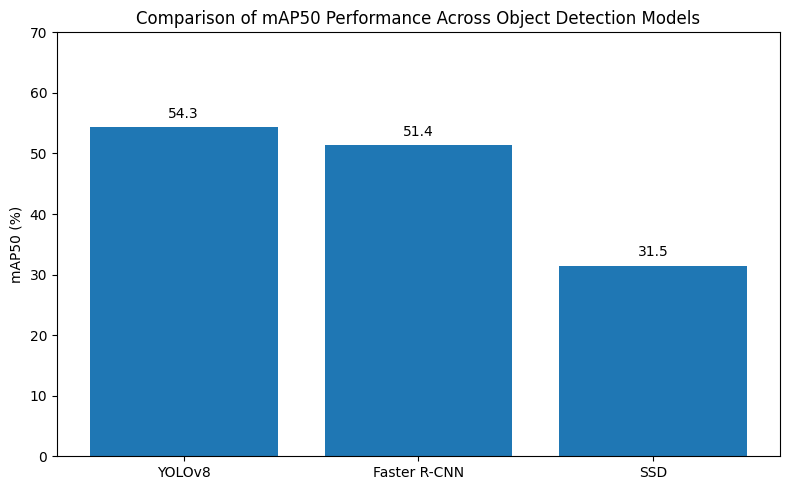

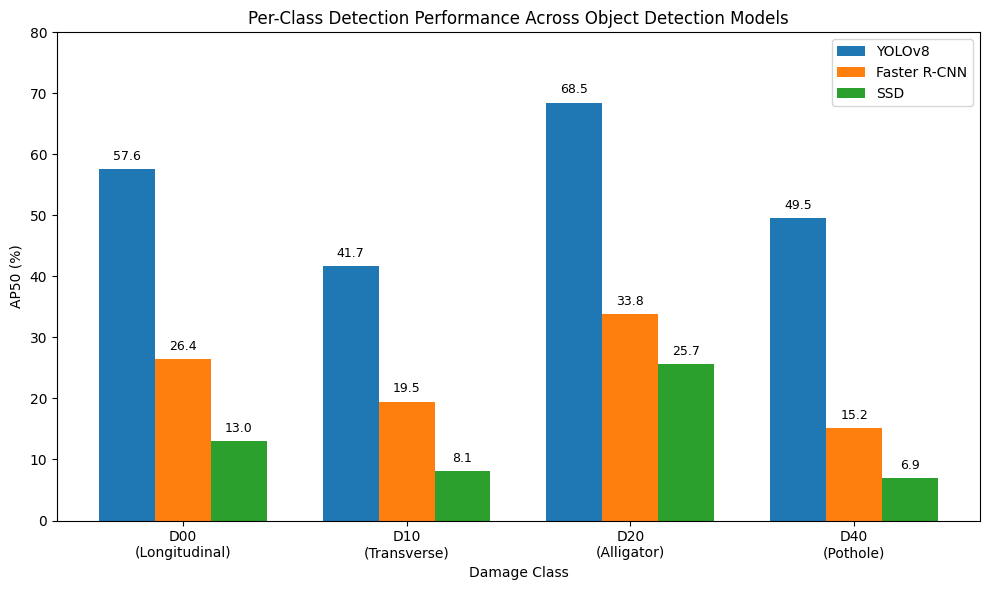

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Figure 2: Overall mAP50 comparison
# -----------------------------
models = ["YOLOv8", "Faster R-CNN", "SSD"]
map50 = [54.3, 51.4, 31.5]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, map50)
plt.ylabel("mAP50 (%)")
plt.title("Comparison of mAP50 Performance Across Object Detection Models")
plt.ylim(0, 70)

for bar, value in zip(bars, map50):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("figure2_map50_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


# -----------------------------
# Figure 3: Per-class performance comparison
# -----------------------------
classes = ["D00\n(Longitudinal)", "D10\n(Transverse)", "D20\n(Alligator)", "D40\n(Pothole)"]
yolov8 = [57.6, 41.7, 68.5, 49.5]
faster_rcnn = [26.4, 19.5, 33.8, 15.2]
ssd = [13.0, 8.1, 25.7, 6.9]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width, yolov8, width, label="YOLOv8")
bars2 = plt.bar(x, faster_rcnn, width, label="Faster R-CNN")
bars3 = plt.bar(x + width, ssd, width, label="SSD")

plt.xlabel("Damage Class")
plt.ylabel("AP50 (%)")
plt.title("Per-Class Detection Performance Across Object Detection Models")
plt.xticks(x, classes)
plt.ylim(0, 80)
plt.legend()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.savefig("figure3_per_class_performance.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
!pip install ultralytics -q

import xml.etree.ElementTree as ET
from pathlib import Path
import json

JAPAN_PATH = '/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/Data/Japan'

classes = ['D00', 'D10', 'D20', 'D40']

def convert_xml_to_yolo(xml_file, output_dir):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    size = root.find('size')
    img_width = int(size.find('width').text)
    img_height = int(size.find('height').text)

    yolo_lines = []
    for obj in root.findall('object'):
        class_name = obj.find('name').text
        if class_name not in classes:
            continue
        class_id = classes.index(class_name)
        bbox = obj.find('bndbox')

        xmin = float(bbox.find('xmin').text)
        ymin = float(bbox.find('ymin').text)
        xmax = float(bbox.find('xmax').text)
        ymax = float(bbox.find('ymax').text)

        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height
        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height

        yolo_lines.append(f"{class_id} {x_center} {y_center} {width} {height}")

    if yolo_lines:  # Only create file if there are annotations
        output_file = output_dir / (Path(xml_file).stem + '.txt')
        with open(output_file, 'w') as f:
            f.write('\n'.join(yolo_lines))

# Convert train labels
xml_dir = Path(f'{JAPAN_PATH}/train/annotations/')
label_dir = Path(f'{JAPAN_PATH}/train/labels')
label_dir.mkdir(parents=True, exist_ok=True)

xml_files = list(xml_dir.glob('*.xml'))
converted = 0

print(f"Converting {len(xml_files)} annotations...")
for xml_file in xml_files:
    try:
        convert_xml_to_yolo(xml_file, label_dir)
        converted += 1
    except Exception as e:
        print(f"Error in {xml_file.name}: {e}")

print(f"✅ Successfully converted {converted}/{len(xml_files)} labels")

# Create YAML
dataset_yaml = f"""path: {JAPAN_PATH}
train: train/images
val: train/images
nc: 4
names: ['D00', 'D10', 'D20', 'D40']
"""

with open('dataset.yaml', 'w') as f:
    f.write(dataset_yaml)

print("\n🚀 Starting YOLOv8 Training...")
print("⏱️  Expected time: 6-8 hours")
print("📊 Dataset: RDD2022 Japan")

# Enable GPU first!
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

results = model.train(
    data='dataset.yaml',
    epochs=50,
    batch=16,
    imgsz=640,
    project='/content/drive/MyDrive/MScResearch/Results',
    name='yolov8_japan_rdd2022',
    save=True,
    device=0,  # GPU
    patience=10
)

# Validate
metrics = model.val()

# Save results
results_dict = {
    'model': 'YOLOv8s',
    'dataset': 'RDD2022 Japan',
    'epochs': 50,
    'images_train': converted,
    'mAP50': float(metrics.box.map50),
    'mAP50-95': float(metrics.box.map),
    'precision': float(metrics.box.mp),
    'recall': float(metrics.box.mr),
}

with open('/content/drive/MyDrive/MScResearch/Results/yolov8_japan_metrics.json', 'w') as f:
    json.dump(results_dict, f, indent=2)

print(f"""
🎉 TRAINING COMPLETE!

📊 RESULTS:
   mAP50: {metrics.box.map50:.3f}
   mAP50-95: {metrics.box.map:.3f}
   Precision: {metrics.box.mp:.3f}
   Recall: {metrics.box.mr:.3f}

 Saved to: /content/drive/MyDrive/MScResearch/Results/

✅ WEEK 1 DONE! Now train Faster R-CNN + SSD!
""")

Converting 10506 annotations...
✅ Successfully converted 10506/10506 labels

🚀 Starting YOLOv8 Training...
⏱️  Expected time: 6-8 hours
📊 Dataset: RDD2022 Japan
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=

## Import libraries

In [ ]:
import os
import shutil
import json
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from google.colab import drive
import gdown
import zipfile

#Datasets preperations

In [ ]:

#%% create folders
def create_folder(path):
    if not os.path.exists(path):
        os.makedirs(path)

create_folder('data')
create_folder('data/rdd2022')
create_folder('data/rdd2018')
create_folder('data/crackforest')
create_folder('data/gaps')


In [ ]:
#Unzip RDD2022
%cd data/rdd2022
!unzip RDD2022_released_through_CRDDC2022.zip

/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/rdd2022
Archive:  RDD2022_released_through_CRDDC2022.zip
 extracting: RDD2022/China_Drone.zip  
 extracting: RDD2022/China_MotorBike.zip  
 extracting: RDD2022/Czech.zip       
 extracting: RDD2022/India.zip       
 extracting: RDD2022/Japan.zip       
 extracting: RDD2022/Norway.zip      
 extracting: RDD2022/United_States.zip  


In [ ]:
!git clone https://github.com/sekilab/RoadDamageDetector data/rdd2018

Cloning into 'data/rdd2018'...
remote: Enumerating objects: 517, done.
remote: Counting objects: 100% (154/154), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 517 (delta 130), reused 97 (delta 97), pack-reused 363 (from 1)
Receiving objects: 100% (517/517), 9.19 MiB | 25.64 MiB/s, done.
Resolving deltas: 100% (264/264), done.


In [ ]:
# CrackForest from GitHub
!git clone https://github.com/cuilimeng/CrackForest-dataset data/crackforest

fatal: destination path 'data/crackforest' already exists and is not an empty directory.


In [ ]:
%cd data/

import os

#%% create folders
def create_folder(path):
    if not os.path.exists(path):
        os.makedirs(path)

create_folder('preprocess/images')
create_folder('preprocess/labels')
create_folder('train/images')
create_folder('train/labels')
create_folder('valid/images')
create_folder('valid/labels')
create_folder('test/images')
create_folder('test/labels')

/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data


In [ ]:
# Unified class mapping (combining all datasets)
UNIFIED_CLASSES = {
    0: "longitudinal_crack",    # D00 in RDD
    1: "transverse_crack",       # D10 in RDD
    2: "alligator_crack",        # D20 in RDD
    3: "pothole",                # D40 in RDD
    4: "crack_general",          # CrackForest
    5: "surface_deterioration"   # GAPs additional classes
}

In [ ]:
def convert_to_yolo_format(bbox, img_width, img_height, class_id):
    """
    Convert bounding box to YOLO format
    bbox: [x_min, y_min, x_max, y_max] or [x_min, y_min, width, height]
    Returns: [class_id, x_center_norm, y_center_norm, width_norm, height_norm]
    """
    if len(bbox) == 4:
        x_min, y_min, x_max, y_max = bbox
        width = x_max - x_min
        height = y_max - y_min
    else:
        x_min, y_min, width, height = bbox
        x_max = x_min + width
        y_max = y_min + height

    # Calculate center and normalize
    x_center = (x_min + x_max) / 2.0 / img_width
    y_center = (y_min + y_max) / 2.0 / img_height
    width_norm = width / img_width
    height_norm = height / img_height

    # Clamp values between 0 and 1
    x_center = max(0, min(1, x_center))
    y_center = max(0, min(1, y_center))
    width_norm = max(0, min(1, width_norm))
    height_norm = max(0, min(1, height_norm))

    return [class_id, x_center, y_center, width_norm, height_norm]

def merge_dataset(source_dir, split, dataset_name, class_mapping):
    """
    Merge a dataset into the unified structure
    """
    print(f"   Merging {dataset_name} ({split} split)...")

    image_count = 0

    # This is a simplified version - you'll need to adapt based on actual dataset structure
    # Each dataset has different annotation formats

    # For RDD datasets (already in YOLO format typically)
    if dataset_name.startswith("rdd"):
        src_images = f"{source_dir}/images/{split}"
        src_labels = f"{source_dir}/labels/{split}"

        if os.path.exists(src_images):
            for img_file in os.listdir(src_images):
                if img_file.endswith(('.jpg', '.png', '.jpeg')):
                    # Copy image
                    src_img = f"{src_images}/{img_file}"
                    dst_img = f"images/{split}/{dataset_name}_{img_file}"
                    shutil.copy(src_img, dst_img)

                    # Copy label (if exists)
                    label_file = img_file.replace('.jpg', '.txt').replace('.png', '.txt')
                    src_label = f"{src_labels}/{label_file}"
                    dst_label = f"labels/{split}/{dataset_name}_{label_file}"

                    if os.path.exists(src_label):
                        shutil.copy(src_label, dst_label)

                    image_count += 1

    print(f"   ✅ Merged {image_count} images from {dataset_name}")
    return image_count

# Merge all datasets
print("\n📦 Merging datasets...")

total_train = 0
total_val = 0
total_test = 0

# RDD2022
try:
    total_train += merge_dataset(f"data/rdd2022", "train", "rdd2022", {})
    total_val += merge_dataset(f"data/rdd2022", "valid", "rdd2022", {})
    total_test += merge_dataset(f"data/rdd2022", "test", "rdd2022", {})
except Exception as e:
    print(f"   ⚠️  Error merging RDD2022: {e}")

# RDD2018
try:
    total_train += merge_dataset(f"data/rdd2018", "train", "rdd2018", {})
    total_val += merge_dataset(f"data/rdd2018", "val", "rdd2018", {})
    total_test += merge_dataset(f"data/rdd2018", "test", "rdd2018", {})
except Exception as e:
    print(f"   ⚠️  Error merging RDD2018: {e}")

print(f"\n✅ Merged dataset statistics:")
print(f"   Train: {total_train} images")
print(f"   Val: {total_val} images")
print(f"   Test: {total_test} images")
print(f"   Total: {total_train + total_val + total_test} images")



📦 Merging datasets...
   Merging rdd2022 (train split)...
   ⚠️  Error merging RDD2022: name 'os' is not defined
   Merging rdd2018 (train split)...
   ⚠️  Error merging RDD2018: name 'os' is not defined

✅ Merged dataset statistics:
   Train: 0 images
   Val: 0 images
   Test: 0 images
   Total: 0 images


In [ ]:
#Unzip RDD2022
%cd rdd2022/RDD2022
!unzip Norway.zip
!unzip United_States.zip
!unzip India.zip

Streaming output truncated to the last 5000 lines.
  inflating: India/train/images/India_003469.jpg  
  inflating: India/train/images/India_003471.jpg  
  inflating: India/train/images/India_003472.jpg  
  inflating: India/train/images/India_003473.jpg  
  inflating: India/train/images/India_003475.jpg  
  inflating: India/train/images/India_003478.jpg  
  inflating: India/train/images/India_003479.jpg  
  inflating: India/train/images/India_003480.jpg  
  inflating: India/train/images/India_003481.jpg  
  inflating: India/train/images/India_003482.jpg  
  inflating: India/train/images/India_003483.jpg  
  inflating: India/train/images/India_003485.jpg  
  inflating: India/train/images/India_003486.jpg  
  inflating: India/train/images/India_003488.jpg  
  inflating: India/train/images/India_003489.jpg  
  inflating: India/train/images/India_003490.jpg  
  inflating: India/train/images/India_003491.jpg  
  inflating: India/train/images/India_003493.jpg  
  inflating: India/train/images




* Outputs per training example: 2
* Flip: Horizontal, Vertical
* 90° Rotate: Clockwise, Counter-Clockwise, Upside Down
* Crop: 0% Minimum Zoom, 20% Maximum Zoom
* Crop: 0% Minimum Zoom, 20% Maximum Zoom
* Saturation: Between -30% and +30%
* Brightness: Between -25% and +25%
* Noise: Up to 5% of pixels
* Adding Filters







In [ ]:
%cd yolov8/data/

import cv2 as cv
import numpy as np
import os

# define paths
input_image_dir = "image/"
input_label_dir = "label/"
output_image_dir = "preprocess/images"
output_label_dir = "preprocess/labels"

# define variables and intialize the values
sigma_s=10
sigma_r=0.1
kernel_size=15
angle=0
mean=0
std=10
occ_size = 40
num_augmentations=1
num=0

#####################################################
# Define defocus filter function for images
def defocus_filter_image(img):
    img = img.astype(np.float32) # convert to float32
    img = cv.bilateralFilter(img, -1, sigma_s, sigma_r) # apply bilateral filter
    img = img.astype(np.uint8) # convert to uint8
    return img

# Define defocus filter function for labels
def defocus_filter_label(label):
    label[:, 1:5] = np.round(label[:, 1:5]) # round bounding box coordinates to integers
    return label

###################################################
# Define motion blur filter function for images
def motion_blur_filter_image(img):
    # Create a defocus kernel
    kernel = np.zeros((kernel_size, kernel_size)) # create kernel
    kernel[int((kernel_size-1)/2), :] = np.ones(kernel_size) # fill kernel with ones
    kernel = cv.warpAffine(kernel, cv.getRotationMatrix2D((kernel_size/2-0.5, kernel_size/2-0.5), angle, 1.0), (kernel_size, kernel_size)) # rotate kernel
    kernel = kernel / kernel_size # normalize kernel

    # Apply the filter
    img = cv.filter2D(img, -1, kernel) # apply filter
    return img

# Define motion blur filter function for labels
def motion_blur_filter_label(label, blurred_image, image):
    blurred_label = label
    # Adjust bounding box coordinates
    blurred_label[:, 1] = (blurred_label[:, 1] + blurred_label[:, 3] / 2) * (blurred_image.shape[1] / image.shape[1])
    blurred_label[:, 2] = (blurred_label[:, 2] + blurred_label[:, 4] / 2) * (blurred_image.shape[0] / image.shape[0])
    blurred_label[:, 3] *= (blurred_image.shape[1] / image.shape[1])
    blurred_label[:, 4] *= (blurred_image.shape[0] / image.shape[0])
    return blurred_label

###################################################

# Define part occultation filter function for images
def part_occultation_filter_image(img):
    img = img.astype(np.float32) # convert to float32
    img = cv.bilateralFilter(img, -1, sigma_s, sigma_r) # apply bilateral filter
    img = img.astype(np.uint8) # convert to uint8
    img = motion_blur_filter_image(img) # apply motion blur filter
    return img

# Define part occultation filter function for labels
def part_occultation_filter_label(label, img_shape):
    # get x and y dimensions of the image
    x, y, _ = img_shape

    # randomly select location for occlusion
    x_rand, y_rand = np.random.randint(0, x - occ_size), np.random.randint(0, y - occ_size)

    # find bounding boxes that are not completely occluded
    mask = np.logical_and(
        np.logical_and(label[:,1]>=y_rand, label[:,1]+label[:,3]<=y_rand+occ_size),
        np.logical_and(label[:,2]>=x_rand, label[:,2]+label[:,4]<=x_rand+occ_size)
    )
    label = label[mask]

    # adjust bounding box coordinates
    label[:, 1] -= y_rand
    label[:, 2] -= x_rand

    return label
###################################################

# Define gaussian noise filter function for images
def gaussian_noise_filter_image(img):
    noise = np.random.normal(mean, std, img.shape)
    img_noisy = img.astype(np.float32) + noise
    img_noisy = np.clip(img_noisy, 0, 255).astype(np.uint8)
    return img_noisy

###################################################

# Loop over the input images and apply the data augmentation filter functions
for file_name in os.listdir(os.path.join(input_image_dir)):
    #count
    num=num+1

    # Load the image and label
    img = cv.imread(os.path.join(input_image_dir, file_name))
    label = np.loadtxt(os.path.join(input_label_dir, file_name[:-4] + ".txt"), ndmin=2)

    # Apply augmentations to each image and label
    for i in range(num_augmentations):
        # Apply defocus filter
        defocus_image = defocus_filter_image(img)
        defocus_label = label.copy()
        #defocus_label = defocus_filter_label(label)

        # Apply motion blur filter
        blurred_image = motion_blur_filter_image(img)
        blurred_label = label.copy()
        #blurred_label = motion_blur_filter_label(label,blurred_image,img)

        # Apply part occultation filter
        part_occ_image = part_occultation_filter_image(img)
        part_occ_label = label.copy()
        #part_occ_label = part_occultation_filter_label(label, img.shape)

        # Apply gaussian noise filter
        noisy_image = gaussian_noise_filter_image(img)
        noisy_label = label.copy() # no need apply for label filter

        # Save the original image and label to the output folder
        cv.imwrite(os.path.join(output_image_dir, file_name[:-4] + "_original" + str(i+1) + ".jpg"), img)
        np.savetxt(os.path.join(output_label_dir, file_name[:-4] + "_original" + str(i+1) + ".txt"), label, fmt="%d %.8f %.8f %.8f %.8f")

        # Save defocus changes in image and label
        img_file_name = os.path.join(output_image_dir, file_name[:-4] + "_defocus_" + str(i+1) + ".jpg")
        label_file_name = os.path.join(output_label_dir, file_name[:-4] + "_defocus_" + str(i+1) + ".txt")
        cv.imwrite(img_file_name, defocus_image)
        np.savetxt(label_file_name, defocus_label, fmt="%d %.8f %.8f %.8f %.8f")

        # Save motion blur changes in image and label
        img_file_name = os.path.join(output_image_dir, file_name[:-4] + "_motion_blur_" + str(i+1) + ".jpg")
        label_file_name = os.path.join(output_label_dir, file_name[:-4] + "_motion_blur_" + str(i+1) + ".txt")
        cv.imwrite(img_file_name, blurred_image)
        np.savetxt(label_file_name, blurred_label, fmt="%d %.8f %.8f %.8f %.8f")

        # Save part occultation changes in image and label
        img_file_name = os.path.join(output_image_dir, file_name[:-4] + "_part_occ_" + str(i+1) + ".jpg")
        label_file_name = os.path.join(output_label_dir, file_name[:-4] + "_part_occ_" + str(i+1) + ".txt")
        cv.imwrite(img_file_name, part_occ_image)
        np.savetxt(label_file_name, part_occ_label, fmt="%d %.8f %.8f %.8f %.8f")

        # Save the gaussian noise image and label
        img_file_name = os.path.join(output_image_dir, file_name[:-4] + "_gaussian_noise_" + str(i+1) + ".jpg")
        label_file_name = os.path.join(output_label_dir, file_name[:-4] + "_gaussian_noise_" + str(i+1) + ".txt")
        cv.imwrite(img_file_name, noisy_image)
        np.savetxt(label_file_name, noisy_label, fmt="%d %.8f %.8f %.8f %.8f")
        print("done ",num)


Streaming output truncated to the last 5000 lines.
done  4351
done  4352
done  4353
done  4354
done  4355
done  4356
done  4357
done  4358
done  4359
done  4360
done  4361
done  4362
done  4363
done  4364
done  4365
done  4366
done  4367
done  4368
done  4369
done  4370
done  4371
done  4372
done  4373
done  4374
done  4375
done  4376
done  4377
done  4378
done  4379
done  4380
done  4381
done  4382
done  4383
done  4384
done  4385
done  4386
done  4387
done  4388
done  4389
done  4390
done  4391
done  4392
done  4393
done  4394
done  4395
done  4396
done  4397
done  4398
done  4399
done  4400
done  4401
done  4402
done  4403
done  4404
done  4405
done  4406
done  4407
done  4408
done  4409
done  4410
done  4411
done  4412
done  4413
done  4414
done  4415
done  4416
done  4417
done  4418
done  4419
done  4420
done  4421
done  4422
done  4423
done  4424
done  4425
done  4426
done  4427
done  4428
done  4429
done  4430
done  4431
done  4432
done  4433
done  4434
done  4435
done  4436
don

#Cloning YoloV8

In [ ]:
%cd model
!pip install ultralytics

from ultralytics import YOLO

# That's it! You're ready to use YOLOv8
model = YOLO('yolov8n.pt')  # Downloads weights automatically

[Errno 2] No such file or directory: 'model'
/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8


In [ ]:
# YOLOv8 Setup
#!pip install ultralytics

#from ultralytics import YOLO

# Create dataset.yaml
dataset_yaml = """
path: content/data/rdd2022/RDD2022/Japan/train
train: images/train
val: images/val
test: images/test

nc: 4
names: ['D00', 'D10', 'D20', 'D40']
"""

with open('dataset.yaml', 'w') as f:
    f.write(dataset_yaml)


# Train (model architecture is automatic)
model = YOLO('yolov8n.pt')
model.train(
    data='dataset.yaml',
    epochs=50,
    batch=16,
    imgsz=640
)

Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0

RuntimeError: Dataset 'dataset.yaml' error ❌ Dataset 'dataset.yaml' images not found, missing path '/content/datasets/content/data/rdd2022/RDD2022/Japan/train/images/val'
Note dataset download directory is '/content/datasets'. You can update this in '/root/.config/Ultralytics/settings.json'

In [ ]:
!find /content/drive/MyDrive/MScResearch -name "Japan" -type d


/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/rdd2022/RDD2022/Japan


In [ ]:
import os

# Get ABSOLUTE path (this fixes the doubling issue)
JAPAN_PATH = '/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/rdd2022/RDD2022/Japan'

# Create YAML
dataset_yaml = f"""path: {JAPAN_PATH}
train: images/train
#val: images/val
test: images/test
nc: 4
names: ['D00', 'D10', 'D20', 'D40']
"""

with open('dataset.yaml', 'w') as f:
    f.write(dataset_yaml)

# Train
from ultralytics import YOLO
model = YOLO('yolov8n.pt')
model.train(data='dataset.yaml', epochs=50, batch=16, imgsz=640)

Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0

RuntimeError: Dataset 'dataset.yaml' error ❌ dataset.yaml 'val:' key missing ❌.
'train' and 'val' are required in all data YAMLs.

In [ ]:
!pip install ultralytics -q

import os
import xml.etree.ElementTree as ET
from pathlib import Path

JAPAN_PATH = '/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/rdd2022/RDD2022/Japan'

classes = ['D00', 'D10', 'D20', 'D40']

def convert_xml_to_yolo(xml_file, output_dir):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    size = root.find('size')
    img_width = int(size.find('width').text)
    img_height = int(size.find('height').text)

    yolo_lines = []

    for obj in root.findall('object'):
        class_name = obj.find('name').text
        if class_name not in classes:
            continue

        class_id = classes.index(class_name)
        bbox = obj.find('bndbox')

        xmin = float(bbox.find('xmin').text)
        ymin = float(bbox.find('ymin').text)
        xmax = float(bbox.find('xmax').text)
        ymax = float(bbox.find('ymax').text)

        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height
        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height

        yolo_lines.append(f"{class_id} {x_center} {y_center} {width} {height}")

    output_file = output_dir / (Path(xml_file).stem + '.txt')
    with open(output_file, 'w') as f:
        f.write('\n'.join(yolo_lines))

for split in ['train', 'test']:
    xml_dir = Path(f'{JAPAN_PATH}/{split}/annotations/xmls')
    label_dir = Path(f'{JAPAN_PATH}/{split}/labels')
    label_dir.mkdir(parents=True, exist_ok=True)

    xml_files = list(xml_dir.glob('*.xml'))
    print(f"{split}: {len(xml_files)} files")

    for xml_file in xml_files:
        convert_xml_to_yolo(xml_file, label_dir)

    print(f"✅ {split} done")

dataset_yaml = f"""path: {JAPAN_PATH}
train: train/images
val: train/images
test: test/images
nc: 4
names: ['D00', 'D10', 'D20', 'D40']
"""

with open('dataset.yaml', 'w') as f:
    f.write(dataset_yaml)

from ultralytics import YOLO
model = YOLO('yolov8n.pt')
model.train(data='dataset.yaml', epochs=50, batch=16, imgsz=640)

train: 0 files
✅ train done
test: 0 files
✅ test done
Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.9.0+cpu CPU (AMD EPYC 7B13)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

RuntimeError: Dataset 'dataset.yaml' error ❌ Dataset 'dataset.yaml' images not found, missing path '/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/rdd2022/RDD2022/Japan/train/images'
Note dataset download directory is '/content/datasets'. You can update this in '/root/.config/Ultralytics/settings.json'

In [ ]:
!pip install ultralytics -q

import os
import xml.etree.ElementTree as ET
from pathlib import Path

# CORRECT path from your screenshots
JAPAN_PATH = '/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/rdd2022/RDD2022/Japan'

classes = ['D00', 'D10', 'D20', 'D40']

def convert_xml_to_yolo(xml_file, output_dir):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    size = root.find('size')
    img_width = int(size.find('width').text)
    img_height = int(size.find('height').text)

    yolo_lines = []

    for obj in root.findall('object'):
        class_name = obj.find('name').text
        if class_name not in classes:
            continue

        class_id = classes.index(class_name)
        bbox = obj.find('bndbox')

        xmin = float(bbox.find('xmin').text)
        ymin = float(bbox.find('ymin').text)
        xmax = float(bbox.find('xmax').text)
        ymax = float(bbox.find('ymax').text)

        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height
        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height

        yolo_lines.append(f"{class_id} {x_center} {y_center} {width} {height}")

    output_file = output_dir / (Path(xml_file).stem + '.txt')
    with open(output_file, 'w') as f:
        f.write('\n'.join(yolo_lines))

# Convert
for split in ['train', 'test']:
    xml_dir = Path(f'{JAPAN_PATH}/{split}/annotations/xmls')
    label_dir = Path(f'{JAPAN_PATH}/{split}/labels')
    label_dir.mkdir(parents=True, exist_ok=True)  # Added parents=True

    xml_files = list(xml_dir.glob('*.xml'))
    print(f"Converting {split}: {len(xml_files)} files...")

    for xml_file in xml_files:
        convert_xml_to_yolo(xml_file, label_dir)

    print(f"✅ Done: {len(xml_files)} labels")

# YAML
dataset_yaml = f"""path: {JAPAN_PATH}
train: train/images
val: train/images
test: test/images
nc: 4
names: ['D00', 'D10', 'D20', 'D40']
"""

with open('dataset.yaml', 'w') as f:
    f.write(dataset_yaml)

print("\n✅ Starting training...")

# Train
from ultralytics import YOLO
model = YOLO('yolov8n.pt')
model.train(data='dataset.yaml', epochs=50, batch=16, imgsz=640)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 824.0/824.0 kB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 31.3 MB/s eta 0:00:00
Converting train: 10506 files...
✅ Done: 10506 labels
Converting test: 0 files...
✅ Done: 0 labels

✅ Starting training...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.9.0+cpu CPU (AMD EPYC 7B13)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10

In [ ]:
!ls -la /content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/rdd2022/RDD2022/Japan/train/
!ls -la /content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV8/data/rdd2022/RDD2022/Japan/train/annotations/

total 2184
drwx------ 2 root root    4096 Aug  9  2022 annotations
drwx------ 2 root root    4096 Aug  9  2022 images
-rw------- 1 root root 2228114 Mar 25 07:19 labels.cache
total 4
drwx------ 2 root root 4096 Aug  9  2022 xmls


# Cloning YOLOV12

In [ ]:
# Clone YoloV12 repo
!git clone https://github.com/sunsmarterjie/yolov12

Cloning into 'yolov12'...
remote: Enumerating objects: 1169, done.
remote: Counting objects: 100% (586/586), done.
remote: Compressing objects: 100% (138/138), done.
remote: Total 1169 (delta 500), reused 448 (delta 448), pack-reused 583 (from 2)
Receiving objects: 100% (1169/1169), 1.92 MiB | 5.26 MiB/s, done.
Resolving deltas: 100% (521/521), done.
Updating files: 100% (333/333), done.


In [ ]:
# Direct to yolo12 directory
%cd yolov12

# Install requirements
!pip install -r requirements.txt

!pip install -e .


/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV12/yolov12
ERROR: flash_attn-2.7.3+cu11torch2.2cxx11abiFALSE-cp311-cp311-linux_x86_64.whl is not a supported wheel on this platform.
Obtaining file:///content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV12/yolov12
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ultralytics (pyproject.toml) ... done
  Created wheel for ultralytics: filename=ultralytics-8.3.63-0.editable-py3-none-any.whl size=20228 sha256=33762d879f31b4eff95b53cf8f8d9661aac879c7323867932f91ea03157ecd54
  Stored in directory: /tmp/pip-ephem-wheel-cache-llhf_e53/wheels/70/d7/81/0ac54ae6869853b5d883754df015c2f3a9e2a22c460c9fc68a
Successfully built ultralytics


# Get data and unzip the file

In [ ]:
import six.moves.urllib as urllib
import os

In [ ]:
import os, urllib.request

url = "https://mycityreport.s3-ap-northeast-1.amazonaws.com/02_RoadDamageDataset/RoadDamageDataset.tar.gz"
out = "RoadDamageDataset.tar.gz"

if not os.path.exists(out):
    urllib.request.urlretrieve(url, out)
    print("Download done")
else:
    print("Already downloaded")

Download done


In [ ]:
%cd yolov12/data/
!tar -zxf ./RoadDamageDataset.tar.gz

[Errno 2] No such file or directory: 'yolov12/data/'
/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV12/yolov12/data


In [ ]:
%cd yolov12/data

try:
    import urllib.request
except ImportError:
    raise ImportError('You should use Python 3.x')

if not os.path.exists('./RoadDamageDataset.tar.gz'):
    url_base = 'https://s3-ap-northeast-1.amazonaws.com/mycityreport/RoadDamageDataset.tar.gz'
    urllib.request.urlretrieve(url_base, './RoadDamageDataset.tar.gz')

    print("Download RoadDamageDataset.tar.gz Done")

else:
    print("You have RoadDamageDataset.tar.gz")

/content/drive/MyDrive/MScResearch/Code/ModelCode/YoloV12/yolov12/data


HTTPError: HTTP Error 403: Forbidden